# 03 · FunnyBirds MCBM — does minimality create grounding?

Notebook 02 established that a standard CBM can report the wrong visible part under controlled swaps. MCBM changes the representation objective, so we now ask a precise question: does compressing each internal slot `z_j` make it depend on the correct pixels?

We do not assume that “less information in `z_j`” means “information came from part `j`.” Those are different properties.


In [1]:
import os, json, re, glob
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
CURATED = Path(os.environ["CURATED_DATA"]); CWD = Path.cwd(); REPO = CWD if (CWD/"analysis").is_dir() else CWD.parent
import sys; sys.path.insert(0, str(REPO/"analysis"))
try:
    from plotting import set_paper_style, PALETTE; set_paper_style()
    CBM_C, MCBM_C = PALETTE["CBM"], PALETTE["MCBM"]
except Exception:
    CBM_C, MCBM_C = "#0072B2", "#D55E00"
plt.rcParams["figure.dpi"]=120
EPS = 1e-3
def parse_stem(stem):
    m=re.match(r"^funnybirds-(vanilla|cbm|mcbm)(?:-g([0-9p]+))?-s(\d+)$", stem)
    if not m: return None
    gamma=float(m.group(2).replace("p",".")) if m.group(2) else np.nan
    return m.group(1), gamma, int(m.group(3))
def need(p, how):
    ok=Path(p).exists()
    if not ok: print(f"[pending] {p}\n  produce it:  {how}")
    return ok
# ---- seed-aware grounding loaders ----
def load_grounding(prefix):
    """All seeds for a config prefix -> one df with a 'seed' column (None if absent)."""
    fs = sorted(glob.glob(str(CURATED/"grounding"/f"{prefix}-s*.parquet")))
    if not fs: return None
    out=[]
    for f in fs:
        d=pd.read_parquet(f); d["seed"]=int(re.search(r"-s(\d+)\.parquet$", f).group(1)); out.append(d)
    return pd.concat(out, ignore_index=True)
def per_part_seedagg(df, visible_only=True):
    """per (seed,part) retained_frac -> per-part mean/std/count across seeds."""
    d = df[df["changed_frac"]>EPS] if (visible_only and "changed_frac" in df.columns) else df
    g = d.groupby(["seed","part"]).agg(pi=("p_intact","mean"), pr=("p_removed","mean"))
    g["rf"] = g.pr/g.pi
    return g["rf"].groupby("part").agg(["mean","std","count"])


## Model definitions and variables

Both models compute `x → z → (c_preds, y_pred)` with 26 scalar slots `z_j`.

CBM minimizes

`L_CBM = L_y + β L_c`,

where `L_y` is species cross-entropy and `L_c` is the sum of concept losses.

MCBM minimizes

`L_MCBM = L_y + β L_c + γ L_z`,

`L_z = Σ_j 0.2 mean((z_j − (6c_j−3))²)`.

Thus `c_j=1` pulls `z_j` toward `+3`; `c_j=0` pulls it toward `−3`. Training also adds Gaussian noise before the concept and species heads.

**Minimality** means that images sharing the same label `c_j` should produce nearly the same `z_j`, removing image details not needed to state `c_j`.

It can reduce stored interconcept information—for example, wing detail retained inside `z_tail`. It does **not** force `z_tail` to read tail pixels. A body-based rule that outputs exactly `+3` for the correct tail label satisfies minimality perfectly.

Likewise, tail pixels could be used to compute `z_beak`; if they produce the correct `±3` beak label, this loss does not detect the wrong input source.

Quantities used below:

- `margin = z_donor,cf − z_source,cf`;
- `ordering_correct = 1[margin>0]`;
- `donor_shift = z_donor,cf − z_donor,orig`;
- `gap_closed = donor_shift / (z_source,orig − z_donor,orig)`.

`gap_closed` is normalized: it reports the fraction of that model's own original donor deficit that was closed, allowing comparison across different raw `z` scales.


## 1 · Did `γ` actually change the representation?

A grounding result cannot test minimality if the extra penalty did not affect `z`. For every `γ`, measure target error `L_z`, mean `|z|`, species accuracy, and concept accuracy.

If `L_z` and `|z|` change while accuracies remain stable, minimality altered the representation without simply breaking the model.


,gamma,rep_loss,mean_abs_z,task_acc,concept_acc,n_seeds
0,0.0,405.565,17.564,0.745,0.993,3
1,0.1,1.389,3.231,0.754,0.995,2
2,0.3,0.312,3.157,0.750,0.994,3
3,1.0,0.183,3.054,0.745,0.995,3
4,3.0,0.157,2.982,0.746,0.995,3
5,5.0,0.150,3.025,0.748,0.995,1


SANITY CHECK: γ changed z strongly, mostly between 0 and 0.1. Grounding must now be tested; this plot alone is not a verdict.


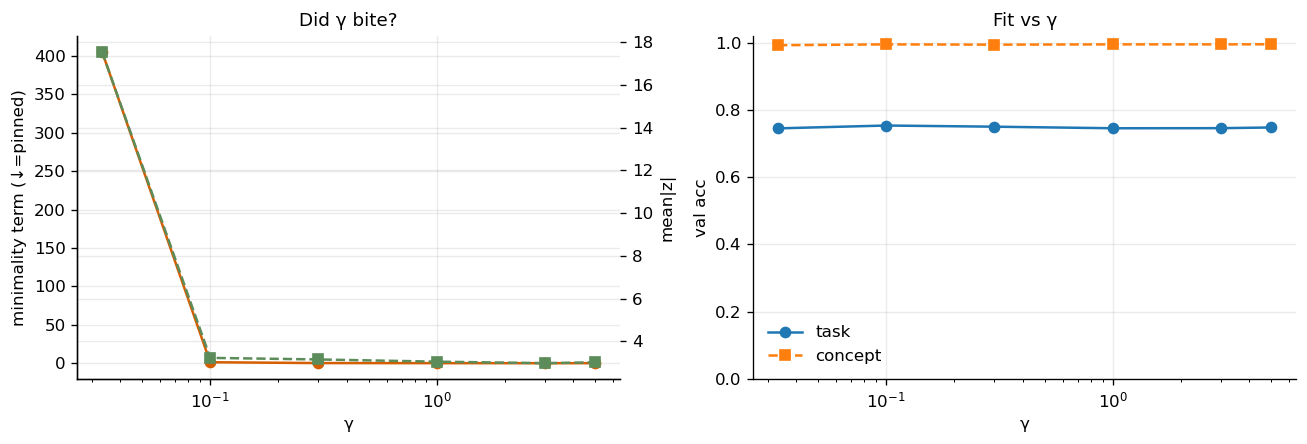

In [2]:
import torch
def zstats_seed(cfg, seed):
    pth = REPO/"external"/"minimal_cbm"/"results"/cfg/str(seed)/"predictions"/"epoch_100.pth"
    if not pth.exists(): return None
    d=torch.load(pth, map_location="cpu", weights_only=False); z,cc=d["z"].float(),d["c"].float()
    if not (np.isfinite(z).all() and np.isfinite(cc).all()): return None
    yp=d["y_preds"]; ta=float((yp.argmax(-1)==d["y"]).float().mean()) if yp.ndim>1 else float((yp==d["y"]).float().mean())
    cp=d["c_preds"]; cp=cp[...,0] if cp.ndim==3 else cp
    return float(((6*cc-3-z)**2).mean()), float(z.abs().mean()), ta, float(((cp>=0.5).float()==cc).float().mean())
rows=[]
for g,tag in [(0,"g0"),(0.1,"g0p1"),(0.3,"g0p3"),(1,"g1"),(3,"g3"),(5,"g5")]:
    for seed in range(1,6):
        s=zstats_seed(f"funnybirds-mcbm-{tag}", seed)
        if s: rows.append((g,seed,*s))
if rows:
    D=pd.DataFrame(rows,columns=["gamma","seed","rep_loss","mean_abs_z","task_acc","concept_acc"])
    Dg=D.groupby("gamma").agg(rep_loss=("rep_loss","mean"),mean_abs_z=("mean_abs_z","mean"),
                              task_acc=("task_acc","mean"),concept_acc=("concept_acc","mean"),n_seeds=("seed","nunique")).reset_index()
    display(Dg.round(3)); floor=(Dg.gamma[Dg.gamma>0].min() or 0.05)/3
    fig,ax=plt.subplots(1,2,figsize=(11,3.8))
    ax[0].plot(Dg.gamma.replace(0,floor),Dg.rep_loss,"o-",color=MCBM_C,label="mean (±3−z)²")
    a0=ax[0].twinx(); a0.plot(Dg.gamma.replace(0,floor),Dg.mean_abs_z,"s--",color="#5B8C5A",label="mean|z|")
    ax[0].set_xscale("log"); ax[0].set_xlabel("γ"); ax[0].set_ylabel("minimality term (↓=pinned)"); a0.set_ylabel("mean|z|"); ax[0].set_title("Did γ bite?")
    ax[1].plot(Dg.gamma.replace(0,floor),Dg.task_acc,"o-",label="task"); ax[1].plot(Dg.gamma.replace(0,floor),Dg.concept_acc,"s--",label="concept")
    ax[1].set_xscale("log"); ax[1].set_xlabel("γ"); ax[1].set_ylabel("val acc"); ax[1].set_ylim(0,1.02); ax[1].legend(); ax[1].set_title("Fit vs γ")
    plt.tight_layout()
    print("SANITY CHECK: γ changed z strongly, mostly between 0 and 0.1. "
          "Grounding must now be tested; this plot alone is not a verdict.")


**What appeared.** The representation changes sharply between `γ=0` and `γ=0.1`, while concept and species accuracy remain similar. Little further compression occurs after `0.1`.

Therefore this experiment mainly compares minimality off with minimality on; it is not six evenly spaced compression levels. We now repeat the exact CBM swap test.


## 2 · Does the replacement concept beat the old concept?

For each part and `γ`, compute

`P(z_donor,cf − z_source,cf > 0)`.

If minimality creates grounding, tail replacement wins should rise toward the strong wing/foot controls. If tail remains low while those controls stay high, compression did not solve the input-source problem.


swap source: /scratch/network/cr7998/cv_emergence_project/curated_data/swap_fixed_v2_attempt2
loaded swaps: {0.0: [1], 0.1: [1], 0.3: [1], 1.0: [1], 3.0: [1], 5.0: [1]}


part,tail,wing,beak,foot,eye
gamma,,,,,
0.0,0.373,0.857,0.574,0.929,0.500
0.1,0.231,0.907,0.580,0.978,0.609
0.3,0.137,0.892,0.577,0.959,0.610
1.0,0.241,0.894,0.765,0.951,0.531
3.0,0.186,0.896,0.767,0.990,0.573
5.0,0.164,0.901,0.726,0.992,0.737


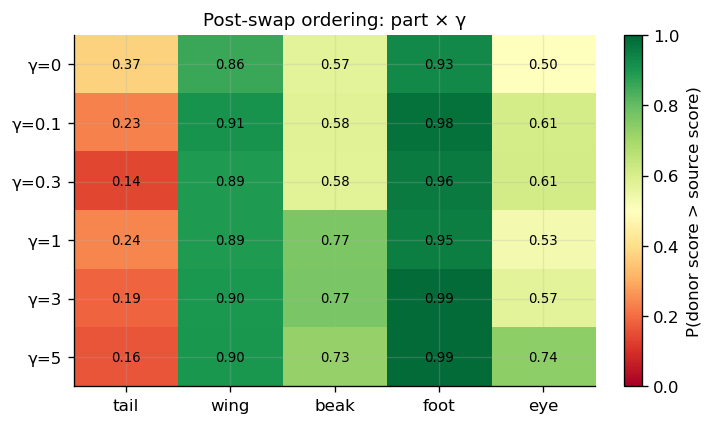

In [3]:
ORDER=["tail","wing","beak","foot","eye"]
def load_swaps():
    # Prefer the semantically validated, byte-matched fixed-render directory.
    # Never mix rows from fixed and legacy renderer runs.
    candidates=[
        CURATED/"swap_fixed_v2_attempt2",
        CURATED/"swap_fixed_v2",
        CURATED/"swap",
    ]
    swap_root=None
    for root in candidates:
        if list(root.glob("funnybirds-mcbm-g*-s*.csv")):
            swap_root=root
            break
    if swap_root is None:
        print("[pending] no standard MCBM combined swap CSVs")
        return None, None

    rows=[]
    for fp in sorted(swap_root.glob("funnybirds-mcbm-g*-s*.csv")):
        m=re.match(r"funnybirds-mcbm-g([0-9p]+)-s(\d+)\.csv$", fp.name)
        if not m:
            continue
        d=pd.read_csv(fp)
        d["gamma"]=float(m.group(1).replace("p","."))
        d["seed"]=int(m.group(2))
        rows.append(d)
    SW=pd.concat(rows,ignore_index=True) if rows else None

    cbs=[f for f in sorted(swap_root.glob("funnybirds-cbm-s*.csv"))
         if re.match(r"funnybirds-cbm-s(\d+)\.csv$", f.name)]
    CB=pd.concat([pd.read_csv(f) for f in cbs],ignore_index=True) if cbs else None
    print("swap source:", swap_root)
    if "fixed_v2" not in swap_root.name:
        print("[PROVISIONAL] legacy independently rendered swaps; do not make exact cross-model causal claims")
    if SW is not None:
        print("loaded swaps:", {
            g:sorted(SW[SW.gamma==g].seed.unique().tolist())
            for g in sorted(SW.gamma.unique())
        })
    return SW, CB

SW,CB=load_swaps()
if SW is not None:
    H=SW.groupby(["gamma","part"]).ordering_correct.mean().unstack().reindex(columns=ORDER)
    display(H.round(3))
    fig,ax=plt.subplots(figsize=(6.2,3.8))
    im=ax.imshow(H.values,cmap="RdYlGn",vmin=0,vmax=1,aspect="auto")
    ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER)
    ax.set_yticks(range(len(H.index))); ax.set_yticklabels([f"γ={g:g}" for g in H.index])
    for i in range(H.shape[0]):
        for j in range(H.shape[1]):
            v=H.values[i,j]
            if np.isfinite(v):
                ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=8)
    ax.set_title("Post-swap ordering: part × γ")
    fig.colorbar(im,fraction=0.046,label="P(donor score > source score)")


**What appeared.** Tail remains poor for every tested `γ`; wing and foot remain strong. Beak and eye vary. Most settings above `γ=0.1` currently have one seed, so their differences are provisional.

The supported conclusion is that turning minimality on does not rescue tail grounding.


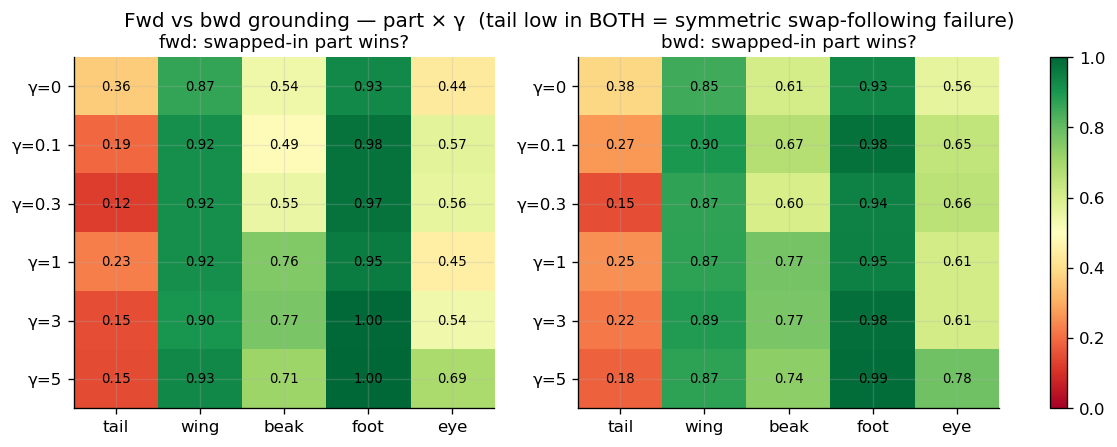

In [4]:
if SW is not None and "direction" in SW.columns:
    fig,axes=plt.subplots(1,2,figsize=(11,3.8)); last_im=None
    for ax,dirn in zip(axes,["fwd","bwd"]):
        H=SW[SW.direction==dirn].groupby(["gamma","part"]).ordering_correct.mean().unstack().reindex(columns=ORDER)
        last_im=ax.imshow(H.values,cmap="RdYlGn",vmin=0,vmax=1,aspect="auto")
        ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER)
        ax.set_yticks(range(len(H.index))); ax.set_yticklabels([f"γ={g:g}" for g in H.index])
        for i in range(H.shape[0]):
            for j in range(H.shape[1]):
                v=H.values[i,j]
                if np.isfinite(v): ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=8)
        ax.set_title(f"{dirn}: swapped-in part wins?")
    fig.colorbar(last_im,ax=axes,fraction=0.046)
    fig.suptitle("Fwd vs bwd grounding — part × γ  (tail low in BOTH = symmetric swap-following failure)")
else: print("[pending] swap CSV with 'direction' column")


Forward and backward swaps agree. This rules against reversed bookkeeping. It establishes symmetric swap-following failure, not by itself a species-backwash mechanism.


### 2a · Coverage and direct donor response

First verify rows, parts, directions, seeds, and checkpoint coverage. Then separate raw donor movement from the old-vs-new ordering:

`donor_shift = z_donor,cf − z_donor,orig`.

Because minimality changes raw scale, also compute

`gap_closed = donor_shift / (z_source,orig − z_donor,orig)`.

`gap_closed=0.25` means the replacement closed 25% of its starting deficit. This test is inserted to determine whether a low tail margin is merely a smaller MCBM number scale or a genuinely weaker response relative to that model's own starting gap.


In [5]:
if SW is not None:
    coverage=(SW.groupby(["gamma","seed","part","direction"])
                .agg(rows=("margin","size"),source_species=("sid_src","nunique"),
                     donor_species=("sid_donor","nunique"),donor_variants=("var_donor","nunique")))
    display(coverage)
    req=["z_new","z_new_orig","z_old","z_old_orig","margin","ordering_correct"]
    print("missing values:",int(SW[[c for c in req if c in SW]].isna().sum().sum()))


rows  source_species  donor_species  donor_variants
gamma seed part direction                                                     
0.0   1    beak bwd         500              35             40               4
                fwd         500              40             35               4
           eye  bwd         500              39             38               3
                fwd         500              38             39               3
           foot bwd         500              38             38               4
                fwd         500              38             38               4
           tail bwd         500              38             37               9
                fwd         500              37             38               9
           wing bwd         500              39             36               6
                fwd         500              36             39               6
0.1   1    beak bwd         500              35             40               4
                fwd         500              40             35               4
           eye  bwd         500              39             38               3
                fwd         500              38             39               3
           foot bwd         500              38             38               4
                fwd         500              38             38               4
           tail bwd         500              38             37               9
                fwd         500              37             38               9
           wing bwd         500              39             36               6
                fwd         500              36             39               6
0.3   1    beak bwd         500              35             40               4
                fwd         500              40             35               4
           eye  bwd         500              39             38               3
                fwd         500              38             39               3
           foot bwd         500              38             38               4
                fwd         500              38             38               4
           tail bwd         500              38             37               9
                fwd         500              37             38               9
           wing bwd         500              39             36               6
                fwd         500              36             39               6
1.0   1    beak bwd         500              35             40               4
                fwd         500              40             35               4
           eye  bwd         500              39             38               3
                fwd         500              38             39               3
           foot bwd         500              38             38               4
                fwd         500              38             38               4
           tail bwd         500              38             37               9
                fwd         500              37             38               9
           wing bwd         500              39             36               6
                fwd         500              36             39               6
3.0   1    beak bwd         500              35             40               4
                fwd         500              40             35               4
           eye  bwd         500              39             38               3
                fwd         500              38             39               3
           foot bwd         500              38             38               4
                fwd         500              38             38               4
           tail bwd         500              38             37               9
                fwd         500              37             38               9
           wing bwd         500              39             36               

missing values: 0


part                                           tail    wing    beak    foot  \
                                       gamma                                  
mean raw shift                         0.0    6.566  16.789  15.663  19.241   
                                       0.1    4.330  15.999  10.085  19.234   
                                       0.3    2.694  16.487  10.525  17.726   
                                       1.0    2.845  15.842  10.273  17.633   
                                       3.0    1.423  15.413   9.276  21.036   
                                       5.0    1.451  15.285   8.489  17.319   
median fraction of original gap closed 0.0    0.151   0.633   0.623   0.700   
                                       0.1    0.233   0.716   0.517   0.771   
                                       0.3    0.123   0.753   0.524   0.763   
                                       1.0    0.112   0.777   0.692   0.896   
                                       3.0    0.030   0.803   0.634   0.983   
                                       5.0    0.026   0.846   0.520   0.915   

part                                             eye  
                                       gamma          
mean raw shift                         0.0    15.560  
                                       0.1     8.822  
                                       0.3     9.698  
                                       1.0     7.704  
                                       3.0     6.866  
                                       5.0     8.311  
median fraction of original gap closed 0.0     0.582  
                                       0.1     0.501  
                                       0.3     0.607  
                                       1.0     0.484  
                                       3.0     0.401  
                                       5.0     0.594

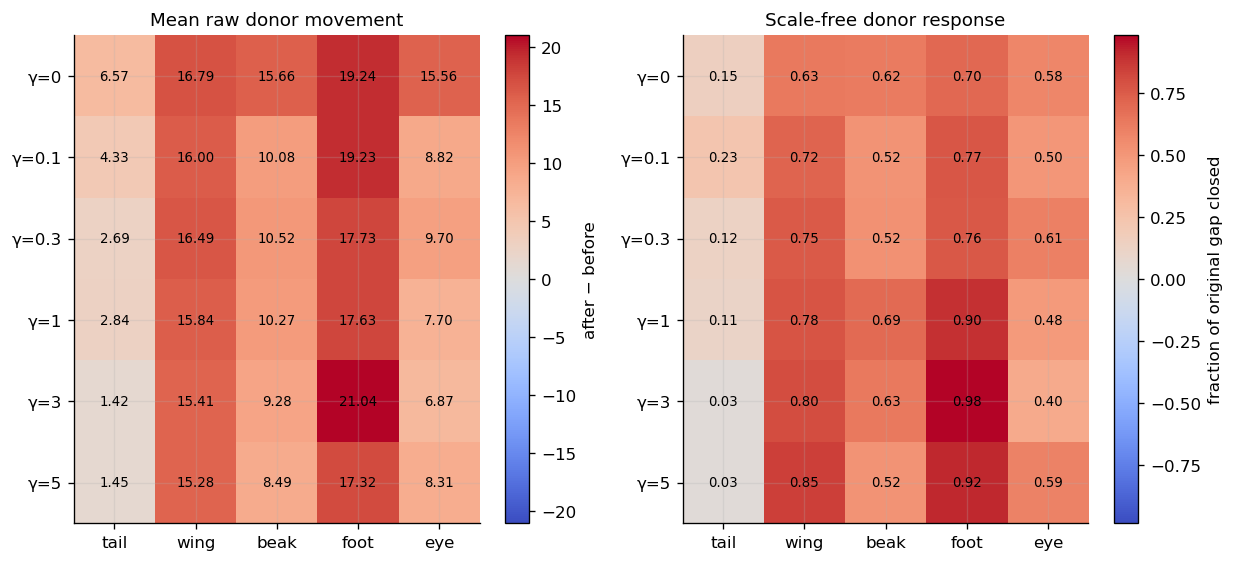

In [6]:
if SW is not None and {"z_new","z_new_orig","z_old_orig"}.issubset(SW.columns):
    d=SW.assign(donor_shift=SW.z_new-SW.z_new_orig,
                original_gap=SW.z_old_orig-SW.z_new_orig)
    d=d[d.original_gap>1e-6]
    d["gap_closed"]=d.donor_shift/d.original_gap
    raw=d.groupby(["gamma","part"]).donor_shift.mean().unstack().reindex(columns=ORDER)
    norm=d.groupby(["gamma","part"]).gap_closed.median().unstack().reindex(columns=ORDER)
    display(pd.concat({"mean raw shift":raw,"median fraction of original gap closed":norm},axis=0).round(3))
    fig,axes=plt.subplots(1,2,figsize=(12,0.58*len(raw)+1.8))
    specs=[(raw,"Mean raw donor movement","after − before"),(norm,"Scale-free donor response","fraction of original gap closed")]
    for ax,(q,title,label) in zip(axes,specs):
        lim=np.nanmax(np.abs(q.values)); im=ax.imshow(q.values,aspect="auto",cmap="coolwarm",vmin=-lim,vmax=lim)
        ax.set(xticks=range(len(q.columns)),xticklabels=q.columns,yticks=range(len(q.index)),yticklabels=[f"γ={g:g}" for g in q.index])
        for r in range(q.shape[0]):
            for k in range(q.shape[1]): ax.text(k,r,f"{q.iloc[r,k]:.2f}",ha="center",va="center",fontsize=8)
        ax.set_title(title); plt.colorbar(im,ax=ax,label=label)
    plt.show()


**What appeared.** Normalized tail response falls from about `0.44` at `γ=0` to about `0.03` at `γ=3–5`, while wing rises and foot remains strong. Therefore tail suppression is not only a raw-scale artifact.

This is compatible with minimality suppressing weak within-label tail variation while a stable body-based label route remains. It is not a complete mechanism proof because the same loss acts on every part.


### 2b · Seed support

Connected means can make one-seed noise look like a smooth `γ` trend. Plot every seed separately. A change is dependable only when it repeats across independently trained seeds.


gamma,0.0,0.1,0.3,1.0,3.0,5.0
seed,,,,,,
1,0.373,0.231,0.137,0.241,0.186,0.164


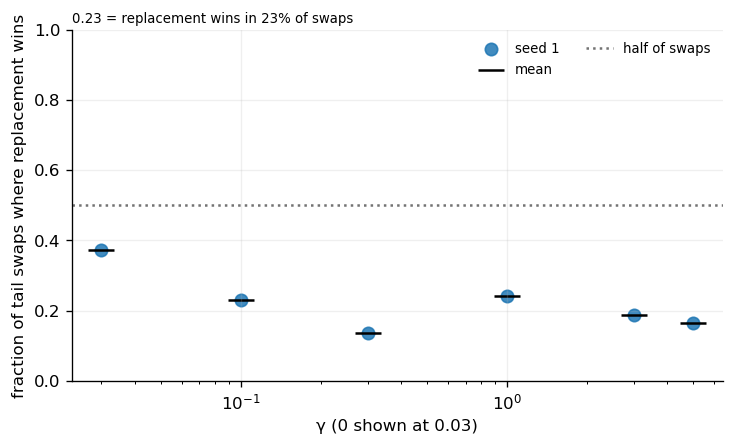

,mean,std,count
gamma,,,
0.0,0.373,NaN,1
0.1,0.231,NaN,1
0.3,0.137,NaN,1
1.0,0.241,NaN,1
3.0,0.186,NaN,1
5.0,0.164,NaN,1


In [7]:
if SW is not None:
    t=(SW[SW.part=="tail"].groupby(["gamma","seed"]).ordering_correct.mean().reset_index())
    display(t.pivot(index="seed",columns="gamma",values="ordering_correct").round(3))
    fig,ax=plt.subplots(figsize=(7,3.8))
    for seed,d in t.groupby("seed"):
        x=[g if g>0 else 0.03 for g in d.gamma]
        ax.scatter(x,d.ordering_correct,s=55,label=f"seed {seed}",alpha=.85)
    means=t.groupby("gamma").ordering_correct.agg(["mean","std","count"])
    x=[g if g>0 else 0.03 for g in means.index]
    ax.scatter(x,means["mean"],marker="_",s=260,color="black",label="mean")
    ax.axhline(.5,color="0.45",ls=":",label="half of swaps")
    ax.set_xscale("log"); ax.set_ylim(0,1); ax.set_xlabel("γ (0 shown at 0.03)")
    ax.set_ylabel("fraction of tail swaps where replacement wins")
    ax.text(0,1.02,"0.23 = replacement wins in 23% of swaps",transform=ax.transAxes,fontsize=8); ax.legend(ncol=2,fontsize=8)
    ax.grid(alpha=.2); plt.show()
    display(means.round(3))


**What appeared.** The validated fixed-render comparison currently contains only seed 1 at every `γ`. In that seed, turning minimality on does not rescue tail and the higher settings also remain poor. This is a provisional seed-1 pattern; replication is required before claiming a stable `γ=0` to `γ=0.1` effect or a smooth dose response.


## 3 · Visibility alternative under MCBM

Repeat the CBM visibility control using `pixel_count_cf`. Compare all tail swaps, visible-only tail swaps, and visible-only foot swaps.

If visible-only tail reaches foot, occlusion explains the failure. If it improves but remains far lower, visibility contributes without settling the remaining input source.


,tail_all,tail_visible,foot_visible(grounded)
gamma,,,
0.0,0.373,0.514,0.948
0.1,0.231,0.314,0.992
0.3,0.137,0.205,0.973
1.0,0.241,0.324,0.973
3.0,0.186,0.271,1.000
5.0,0.164,0.221,1.000


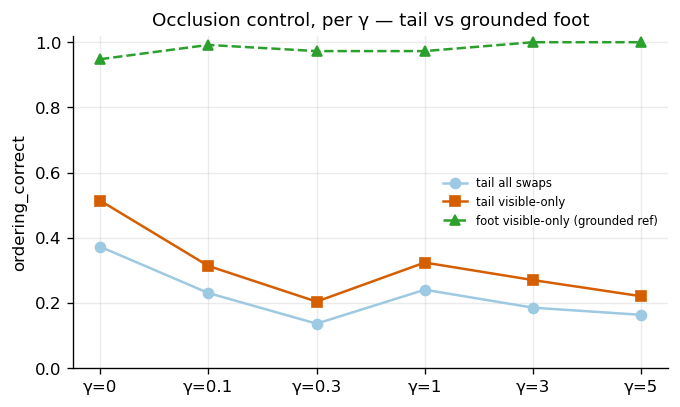

In [8]:
if SW is not None and "pixel_count_cf" in SW.columns:
    allg=SW[SW.part=="tail"].groupby("gamma").ordering_correct.mean()
    visg=SW[(SW.part=="tail")&(SW.pixel_count_cf>=50)].groupby("gamma").ordering_correct.mean()
    footv=SW[(SW.part=="foot")&(SW.pixel_count_cf>=50)].groupby("gamma").ordering_correct.mean()
    D=pd.DataFrame({"tail_all":allg,"tail_visible":visg,"foot_visible(grounded)":footv}); display(D.round(3))
    fig,ax=plt.subplots(figsize=(6.4,3.6)); x=np.arange(len(D))
    ax.plot(x,D["tail_all"],"o-",label="tail all swaps",color="#9ec9e2")
    ax.plot(x,D["tail_visible"],"s-",label="tail visible-only",color=MCBM_C)
    ax.plot(x,D["foot_visible(grounded)"],"^--",label="foot visible-only (grounded ref)",color="#2ca02c")
    ax.set_xticks(x); ax.set_xticklabels([f"γ={g:g}" for g in D.index]); ax.set_ylim(0,1.02)
    ax.set_ylabel("ordering_correct"); ax.legend(fontsize=7); ax.set_title("Occlusion control, per γ — tail vs grounded foot")
else: print("[pending] mcbm swap CSVs with pixel_count_cf")

**What appeared.** Visibility filtering improves tail at every `γ`, but tail remains far below foot. Test-time visibility is a partial explanation. Minimality changes `z`; it does not repair the narrower training conflict in which a non-placeholder tail label remains positive despite negligible visible tail area. Placeholder/removed parts already have an all-zero concept group.


## 4 · Necessity check by deletion

Deletion measures

`retained_frac = p_removed / p_intact`.

This asks whether the old concept remains supported after its pixels disappear. It is weaker than a swap because it does not test which visible replacement wins, but agreement with the swap anomaly strengthens the claim that tail has unusual outside support.


tail retained_frac by γ (mean±std over seeds):


,gamma,mean,std
3,0.0,0.284,0.080
8,0.1,0.358,0.152
13,0.3,0.420,NaN
18,1.0,0.360,NaN
23,3.0,0.265,NaN
28,5.0,0.450,NaN


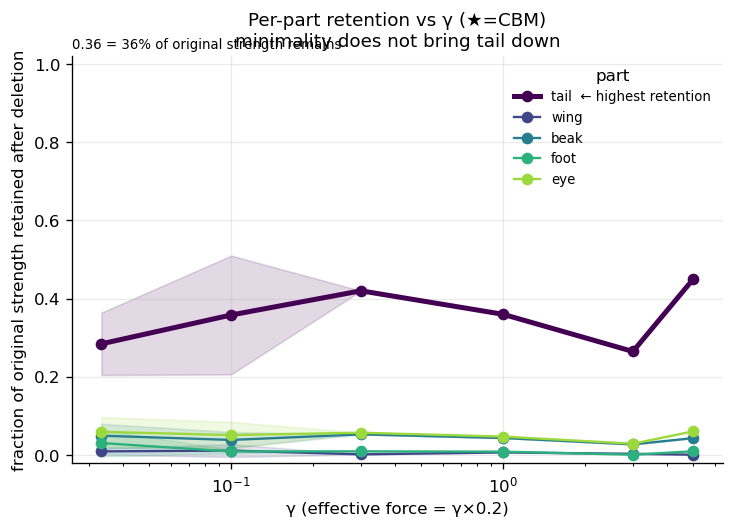

In [9]:
recs=[]
for f in sorted(glob.glob(str(CURATED/"grounding"/"funnybirds-*-s*.parquet"))):
    pr=parse_stem(Path(f).stem)
    if pr is None or pr[0]=="vanilla": continue
    model,gamma,seed=pr; d=pd.read_parquet(f)
    if "changed_frac" in d.columns: d=d[d["changed_frac"]>EPS]
    gg=d.groupby("part").agg(pi=("p_intact","mean"),pr=("p_removed","mean"))
    for part,row in gg.iterrows(): recs.append(dict(model=model,gamma=gamma,seed=seed,part=part,retained_frac=row.pr/row.pi))
P=pd.DataFrame(recs)
if len(P):
    parts=["tail","wing","beak","foot","eye"]
    A=P.groupby(["model","gamma","part"]).retained_frac.agg(["mean","std"]).reset_index()
    mc=A[A.model=="mcbm"]; cbm_pp=A[A.model=="cbm"].set_index("part")["mean"]
    floor=(mc.gamma[mc.gamma>0].min() or 0.05)/3
    fig,ax=plt.subplots(figsize=(7,4.4)); cmap=plt.cm.viridis(np.linspace(0,0.85,len(parts)))
    for part,col in zip(parts,cmap):
        s=mc[mc.part==part].sort_values("gamma");
        if not len(s): continue
        x=s.gamma.replace(0,floor)
        ax.plot(x,s["mean"],"o-",color=col,lw=3 if part=="tail" else 1.4,label=part+("  ← highest retention" if part=="tail" else ""))
        ax.fill_between(x, s["mean"]-s["std"].fillna(0), s["mean"]+s["std"].fillna(0), color=col, alpha=0.15)
        if part in cbm_pp.index: ax.scatter([floor/1.6],[cbm_pp[part]],marker="*",s=90,color=col,zorder=5)
    ax.set_xscale("log"); ax.set_xlabel("γ (effective force = γ×0.2)"); ax.set_ylabel("fraction of original strength retained after deletion")
    ax.text(0,1.02,"0.36 = 36% of original strength remains",transform=ax.transAxes,fontsize=8)
    ax.set_ylim(-0.02,1.02); ax.set_title("Per-part retention vs γ (★=CBM)\nminimality does not bring tail down"); ax.legend(title="part",fontsize=8)
    print("tail retained_frac by γ (mean±std over seeds):")
    display(mc[mc.part=="tail"][["gamma","mean","std"]].sort_values("gamma").round(3))
else: print("[pending] bash analysis/grounding_sweep.sh")


**What appeared.** Tail retains much more strength after deletion than other parts. The curve is noisy and mostly single-seed, so it supports a tail-specific problem but does not establish a smooth `γ` effect.

Deletion and swapping are not contradictory: deletion can lower `z_source`, insertion can raise `z_donor`, and the old source can still remain larger.


## 5 · Does minimality remove stored class information?

Predict species `y` from all reported concepts and from the tail block. This tests information available in the representation, not which pixels computed it.

The tail-only result must be compared with the true-tail-label baseline (approximately `9/50=0.18`), not only random species chance `1/50=0.02`. To measure conditional leakage, compare `species←Z_tail` against `species←C_tail,true` within each true tail variant.


,gamma,c,tail,chance
0,0.0,0.984,0.203,0.02
1,0.1,0.988,0.218,0.02
2,0.3,0.990,0.190,0.02
3,1.0,0.994,0.198,0.02
4,3.0,0.986,0.268,0.02
5,5.0,0.998,0.272,0.02


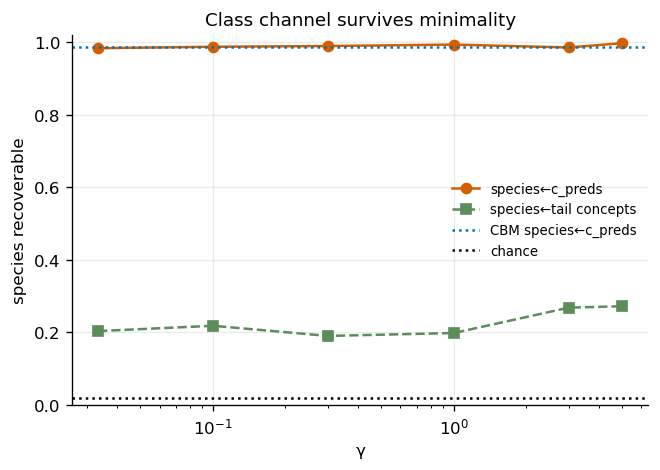

In [10]:
rows=[]
for f in sorted(glob.glob(str(CURATED/"species_probe"/"funnybirds-mcbm-g*-s*.json"))):
    m=re.search(r"-g([0-9p]+)-s(\d+)\.json$", Path(f).name)
    if not m: continue
    S=json.loads(Path(f).read_text())
    rows.append(dict(gamma=float(m.group(1).replace("p",".")), seed=int(m.group(2)),
                     c=S["species_from_cpreds"]["acc"], tail=S["species_from_part_cpreds"].get("tail",{}).get("acc",np.nan),
                     chance=S["chance"]))
if rows:
    D=pd.DataFrame(rows); Dg=D.groupby("gamma").agg(c=("c","mean"),tail=("tail","mean"),chance=("chance","first")).reset_index()
    display(Dg.round(3)); floor=(Dg.gamma[Dg.gamma>0].min() or 0.05)/3
    cbj=sorted(glob.glob(str(CURATED/"species_probe"/"funnybirds-cbm-s*.json")))
    fig,ax=plt.subplots(figsize=(6.2,4))
    ax.plot(Dg.gamma.replace(0,floor),Dg.c,"o-",color=MCBM_C,label="species←c_preds")
    ax.plot(Dg.gamma.replace(0,floor),Dg["tail"],"s--",color="#5B8C5A",label="species←tail concepts")
    if cbj: ax.axhline(np.mean([json.loads(Path(p).read_text())["species_from_cpreds"]["acc"] for p in cbj]),ls=":",color=CBM_C,label="CBM species←c_preds")
    ax.axhline(Dg.chance.iloc[0],ls=":",color="k",label="chance"); ax.set_xscale("log")
    ax.set_xlabel("γ"); ax.set_ylabel("species recoverable"); ax.set_ylim(0,1.02); ax.legend(fontsize=8)
    ax.set_title("Class channel survives minimality")
else: print("[pending] grounding_sweep.sh runs the probe too")

**What appeared.** The full concept vector still predicts species almost perfectly. Tail-only accuracy is only modestly above its label-only baseline at some settings and lacks full seed coverage.

This does not prove tail backwash. More importantly, even perfect MCBM compression could hide a body-based OR-over-species computation by mapping every route to the same `±3` output.


## 6 · Does the concept change influence the species head?

Plot task-head response against tail `margin`. This asks whether a larger donor-tail victory affects species probability. It is not a direct harm metric because a one-tail replacement does not make the whole bird belong to the donor species.


,rows,mean_P_donor,P_donor_above_.5,P_donor_above_.9
model,,,,
MCBM γ=0,1000,0.0137,0.014,0.008
CBM,1000,0.0160,0.015,0.008


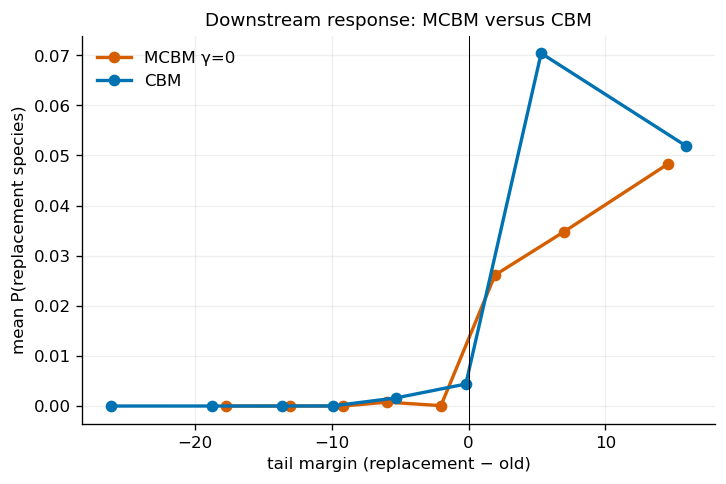

P(donor)>.5 is only a proxy for donor dominance; exact class-flip rate requires saving predicted_class in future CSVs.


In [11]:
if SW is not None and "p_cf_donor" in SW.columns:
    fig,ax=plt.subplots(figsize=(6.8,4.2))
    series=[]
    g0=sorted(SW.gamma.unique())[0]
    series.append((f"MCBM γ={g0:g}",SW[(SW.part=="tail")&(SW.gamma==g0)].copy(),MCBM_C))
    if CB is not None: series.append(("CBM",CB[CB.part=="tail"].copy(),CBM_C))
    summary=[]
    for label,t,col in series:
        if len(t)>8:
            t["mb"]=pd.qcut(t.margin,8,duplicates="drop")
            gb=t.groupby("mb",observed=True).agg(mx=("margin","mean"),my=("p_cf_donor","mean"))
            ax.plot(gb.mx,gb.my,"o-",lw=2,label=label,color=col)
        summary.append({"model":label,"rows":len(t),"mean_P_donor":t.p_cf_donor.mean(),
                        "P_donor_above_.5":(t.p_cf_donor>.5).mean(),"P_donor_above_.9":(t.p_cf_donor>.9).mean()})
    display(pd.DataFrame(summary).set_index("model").round(4))
    ax.axvline(0,color="k",lw=.6); ax.set(xlabel="tail margin (replacement − old)",ylabel="mean P(replacement species)",title="Downstream response: MCBM versus CBM")
    ax.legend(); ax.grid(alpha=.2); plt.show()
    print("P(donor)>.5 is only a proxy for donor dominance; exact class-flip rate requires saving predicted_class in future CSVs.")
else: print("[pending] swap CSV with p_cf_donor")


**What appeared.** Donor-species probability rises modestly as the donor tail wins. The demonstrated failure remains at the concept/explanation level; this graph does not show widespread classification damage.


## 6a · Catch-up: standard MCBM analyses from the original notebook

These panels restore the important pre-RL work that disappeared when notebook 03
was shortened. They do **not** use the relabeled models.

For every panel the order is: question, prediction, literal output, alternative
explanation, discriminating check, limited conclusion, next question. Literal
observations must be written only after the executed figure is inspected.


### 6a.1 · Does the result agree in both swap directions?

**Question.** Does the replacement win for `body_A + part_B` and for
`body_B + part_A`, or is a bookkeeping direction creating the result?

**Prediction.** A real part-grounding pattern should have similar forward and
backward values. Strong disagreement would make the combined average unsafe.

The figure reports `P(margin>0)` separately for both directions. Green means the
replacement concept wins; red means the old source concept wins.


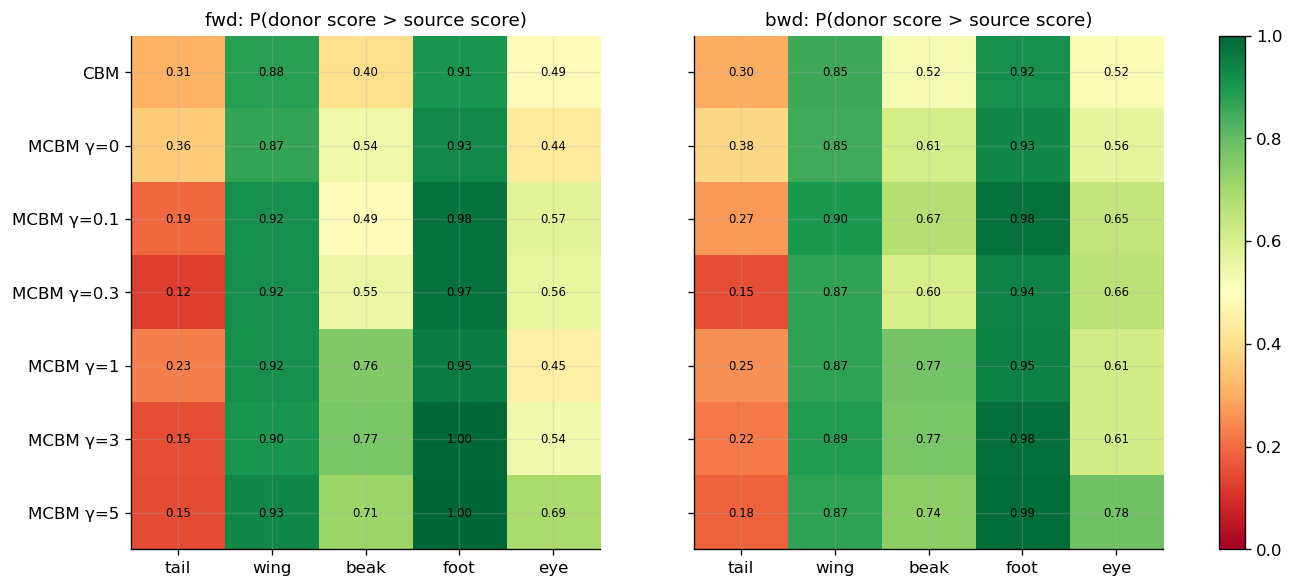

In [12]:
if SW is not None and "direction" in SW:
    frames=[]
    if CB is not None:
        frames.append(("CBM",CB))
    frames += [(f"MCBM γ={g:g}",d) for g,d in SW.groupby("gamma")]
    labels=[x[0] for x in frames]
    fig,axes=plt.subplots(1,2,figsize=(12,0.48*len(labels)+2.2),sharey=True)
    for ax,direction in zip(axes,["fwd","bwd"]):
        H=pd.DataFrame(
            [d[d.direction==direction].groupby("part").ordering_correct.mean()
             for _,d in frames],
            index=labels,
        ).reindex(columns=ORDER)
        im=ax.imshow(H.values,cmap="RdYlGn",vmin=0,vmax=1,aspect="auto")
        ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
        ax.set_title(f"{direction}: P(donor score > source score)")
        for i in range(H.shape[0]):
            for j in range(H.shape[1]):
                if np.isfinite(H.iloc[i,j]):
                    ax.text(j,i,f"{H.iloc[i,j]:.2f}",ha="center",va="center",fontsize=7)
    fig.colorbar(im,ax=axes,fraction=0.025)
else:
    print("[pending] direction-labelled standard swap rows")


**Discriminating check.** Compare each forward cell directly with its
backward partner. If they disagree, inspect pair construction before interpreting
the average.

**Limited conclusion rule.** Agreement can rule out a simple reversed-direction
bug. It cannot by itself prove that the unchanged body caused the failure.

**Next question.** Even when the donor finishes below the source, did the inserted
part move the model in the correct direction?


### 6a.2 · Did the swap move the scores toward the donor?

Define

`response_delta = (z_donor − z_source)_swap − (z_donor − z_source)_original`.

**Question.** Does adding the donor part move the donor-versus-source margin
upward? `response_delta>0` means it did, even if the donor did not finish on top.

**Prediction.** Grounded concepts should usually have positive response. A
positive but small tail response means partial visual sensitivity plus a strong
remaining source/body preference.


,part,beak,eye,foot,tail,wing
gamma,seed,,,,,
0.0,1,29.967,27.593,40.413,18.204,38.982
0.1,1,20.602,19.827,40.947,10.387,36.091
0.3,1,20.327,19.056,39.276,7.710,34.581
1.0,1,21.953,16.618,35.808,8.361,35.327
3.0,1,21.030,17.917,42.156,6.806,34.387
5.0,1,20.720,18.686,35.301,6.272,33.663


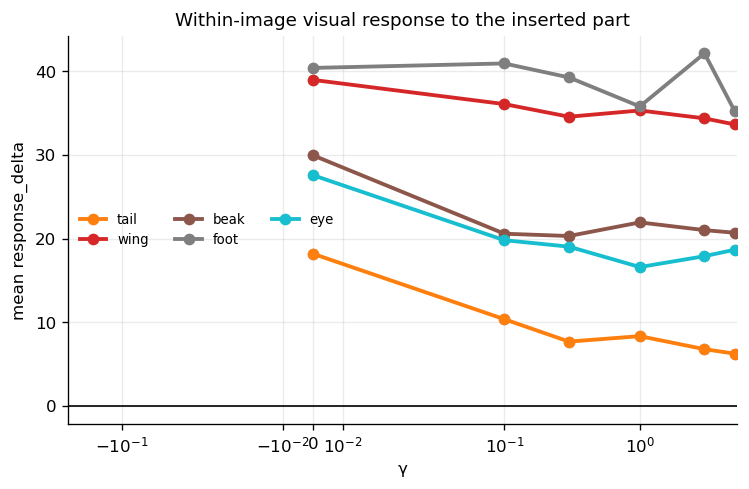

In [13]:
if SW is not None:
    D=SW.copy()
    if "response_delta" not in D:
        needed={"margin","z_new_orig","z_old_orig"}
        if needed.issubset(D.columns):
            D["response_delta"]=D["margin"]-(D["z_new_orig"]-D["z_old_orig"])
    if "response_delta" in D:
        R=(D.groupby(["gamma","seed","part"]).response_delta.mean()
             .reset_index())
        fig,ax=plt.subplots(figsize=(7.2,4.2))
        for part in ORDER:
            p=R[R.part==part]
            for seed,s in p.groupby("seed"):
                ax.plot(s.gamma,s.response_delta,marker="o",alpha=.35,linewidth=1)
            m=p.groupby("gamma").response_delta.mean()
            ax.plot(m.index,m.values,marker="o",linewidth=2.3,label=part)
        ax.axhline(0,color="black",linewidth=1)
        ax.set_xscale("symlog",linthresh=.05)
        ax.set_xlabel("γ"); ax.set_ylabel("mean response_delta")
        ax.set_title("Within-image visual response to the inserted part")
        ax.legend(ncol=3,fontsize=8)
        display(R.pivot_table(index=["gamma","seed"],columns="part",
                              values="response_delta").round(3))
    else:
        print("[pending] swap rows with original and counterfactual margins")


**Alternative explanation.** A positive mean could be driven by a few
large rows or one seed. Inspect every seed and the distribution before calling it
stable.

**Limited conclusion rule.** Positive `response_delta` supports visual
sensitivity. It does not imply correct final attribution; that still requires the
post-swap margin to cross zero.

**Next question.** Are failures spread across variants, or caused by one bad
concept slot?


### 6a.3 · Which visible variant does each part report?

**Question.** After inserting donor variant `v`, which concept slot has the
largest score within that part group?

Rows are donor variants and columns are the reported argmax variants. A bright
diagonal means correct attribution. A bright column means many inputs collapse
onto one default answer.


diagonal fractions: {'tail': 0.278, 'wing': 0.811, 'beak': 0.55, 'foot': 0.926, 'eye': 0.495}


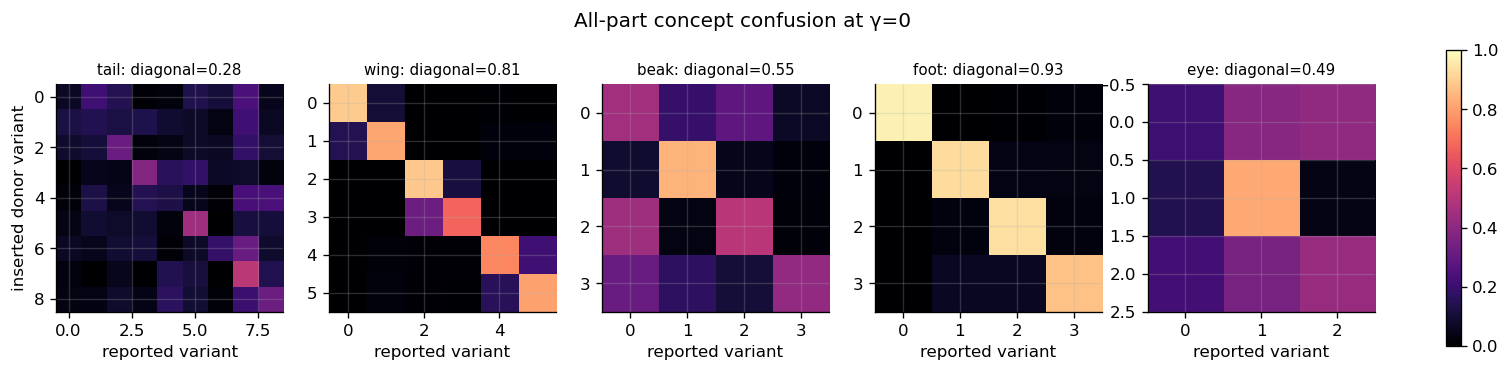

In [14]:
if SW is not None:
    g0=sorted(SW.gamma.unique())[0]
    S0=SW[SW.gamma==g0]
    have=[p for p in ORDER if any(c.startswith(f"z_cf_{p}_") for c in S0.columns)]
    if have:
        fig,axes=plt.subplots(1,len(have),figsize=(3.05*len(have),3.2))
        if len(have)==1: axes=[axes]
        last=None; diags={}
        for ax,p in zip(axes,have):
            cols=sorted([c for c in S0.columns if c.startswith(f"z_cf_{p}_")],
                        key=lambda c:int(c.split("_")[-1]))
            dd=S0[S0.part==p].dropna(subset=cols)
            n=len(cols); pred=dd[cols].values.argmax(1); donor=dd.var_donor.astype(int).values
            M=np.zeros((n,n))
            for a,b in zip(donor,pred):
                if 0<=a<n: M[a,b]+=1
            M=M/M.sum(1,keepdims=True).clip(min=1)
            diags[p]=float((pred==donor).mean())
            last=ax.imshow(M,cmap="magma",vmin=0,vmax=1)
            ax.set_title(f"{p}: diagonal={diags[p]:.2f}",fontsize=9)
            ax.set_xlabel("reported variant")
        axes[0].set_ylabel("inserted donor variant")
        fig.suptitle(f"All-part concept confusion at γ={g0:g}")
        fig.colorbar(last,ax=axes,fraction=.02)
        print("diagonal fractions:",{k:round(v,3) for k,v in diags.items()})
    else:
        print("[pending] z_cf_<part>_<variant> columns")


**Alternative explanation.** Argmax attribution is stricter and
different from the two-slot ordering metric. Read it as a description of
within-part confusion, not a replacement for `margin`.

**Limited conclusion rule.** A repeated off-diagonal column supports
default-concept collapse only when grounded parts processed by the same code show
cleaner diagonals.

**Next question.** Does increasing `gamma` repair these variant assignments, or
does it leave the same broad tail confusion?


#### 6a.3b · Variant confusion across every `gamma`

**Question.** The previous matrix is only `gamma=0`. What happens after the
minimality penalty turns on?

The first panel reports the diagonal fraction for every part and `gamma`: one
means the inserted variant was the largest-scoring slot. The second figure shows
the complete tail confusion matrix at every `gamma`, so a diagonal improvement
can be distinguished from collapse onto one default tail answer.


In [ ]:
if SW is not None and "var_donor" in SW.columns:
    gammas=sorted(SW.gamma.unique())
    diag=pd.DataFrame(index=gammas,columns=ORDER,dtype=float)
    tail_mats={}
    for g in gammas:
        for p in ORDER:
            d=SW[(SW.gamma==g)&(SW.part==p)]
            cols=sorted([c for c in d.columns if c.startswith(f"z_cf_{p}_")],
                        key=lambda c:int(c.split("_")[-1]))
            if not cols:
                continue
            dd=d.dropna(subset=cols)
            donor=dd.var_donor.astype(int).values
            pred=dd[cols].values.argmax(1)
            valid=(donor>=0)&(donor<len(cols))
            if valid.any():
                diag.loc[g,p]=(pred[valid]==donor[valid]).mean()
            if p=="tail":
                n=len(cols); M=np.zeros((n,n))
                for a,b in zip(donor[valid],pred[valid]): M[a,b]+=1
                tail_mats[g]=M/M.sum(1,keepdims=True).clip(min=1)

    fig,ax=plt.subplots(figsize=(7.2,4.2))
    im=ax.imshow(diag.values.astype(float),cmap="RdYlGn",vmin=0,vmax=1,
                 aspect="auto")
    ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER)
    ax.set_yticks(range(len(gammas)))
    ax.set_yticklabels([f"gamma={g:g}" for g in gammas])
    for i in range(len(gammas)):
        for j in range(len(ORDER)):
            v=diag.iloc[i,j]
            if pd.notna(v):
                ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=8)
    ax.set_title("Correct inserted-variant attribution across gamma")
    fig.colorbar(im,ax=ax,label="diagonal fraction")
    display(diag.round(3))

    fig,axes=plt.subplots(2,3,figsize=(12,7),squeeze=False)
    last=None
    for ax,g in zip(axes.flat,gammas):
        M=tail_mats.get(g)
        if M is None:
            ax.axis("off"); continue
        last=ax.imshow(M,cmap="magma",vmin=0,vmax=1)
        ax.set_title(f"gamma={g:g}; diagonal={diag.loc[g,'tail']:.2f}")
        ax.set_xlabel("reported tail variant")
        ax.set_ylabel("inserted tail variant")
    for ax in list(axes.flat)[len(gammas):]: ax.axis("off")
    if last is not None: fig.colorbar(last,ax=axes,fraction=.02)
    fig.suptitle("Tail confusion across every minimality setting")


**Interpretation rule.** A rising tail diagonal would mean that minimality
improves exact visible-tail attribution. Persistently low diagonals with different
off-diagonal patterns mean the problem is broad rather than one fixed default
slot. These fixed-render values are currently seed 1, so changes between `gamma`
settings remain provisional.

**Next question.** Is the remaining tail variation explained by tail variants,
or does the unchanged source body still matter?


### 6a.4 · Variant first, then source body/species

**Question.** Which source–donor tail combinations fail, and is there additional
variation across source species after acknowledging that each species has a fixed
tail variant?

The first panel shows variant-pair follow rates. The second shows raw source
species violation rates, coloured by the source tail variant. The third subtracts
the mean failure rate of each source variant so species sharing a variant can be
compared.


,sid_src,var_src,violation,variant_mean,within_variant_residual
14,14,6,0.950,0.493,0.457
43,43,2,1.000,0.616,0.384
17,17,2,0.950,0.616,0.334
4,4,1,0.960,0.688,0.272
24,24,3,0.829,0.576,0.253
23,23,5,0.900,0.656,0.244
26,26,5,0.900,0.656,0.244
49,49,3,0.800,0.576,0.224
36,36,8,0.800,0.605,0.195
35,35,2,0.800,0.616,0.184


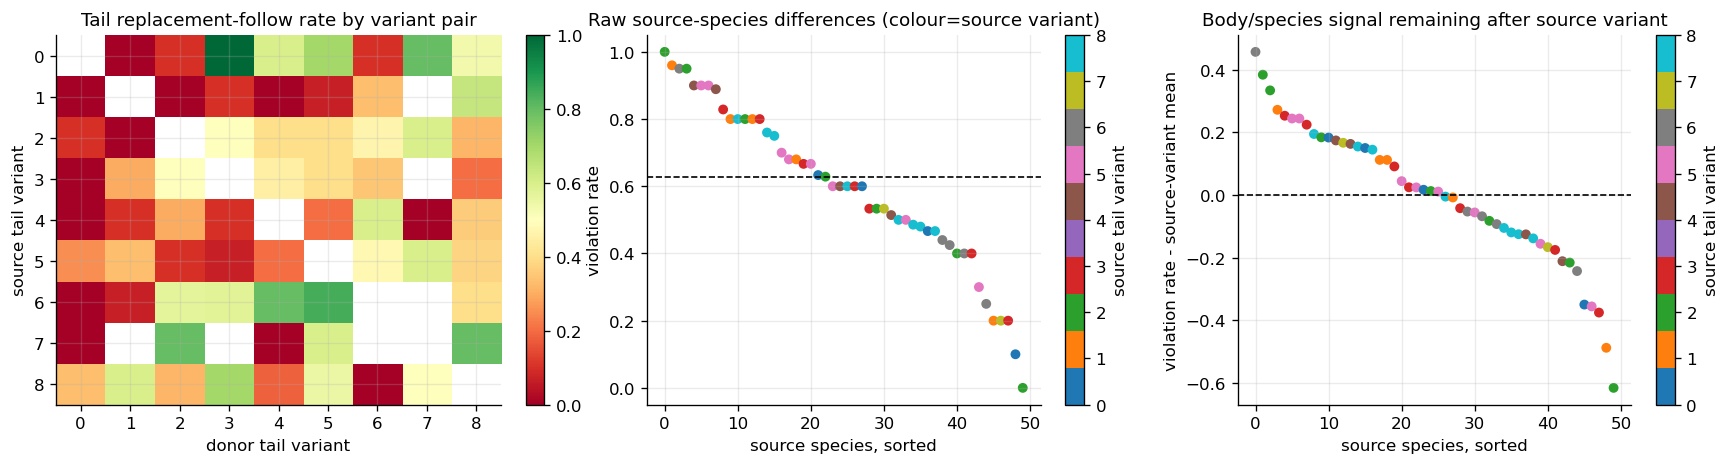

In [15]:
if SW is not None and {"var_src","var_donor","sid_src"}.issubset(SW.columns):
    g0=sorted(SW.gamma.unique())[0]
    t=SW[(SW.gamma==g0)&(SW.part=="tail")].copy()
    P=t.groupby(["var_src","var_donor"]).ordering_correct.mean().unstack()
    raw=(t.assign(violation=~t.ordering_correct.astype(bool))
          .groupby(["sid_src","var_src"]).violation.mean().reset_index()
          .sort_values("violation",ascending=False))
    raw["variant_mean"]=raw.groupby("var_src").violation.transform("mean")
    raw["within_variant_residual"]=raw.violation-raw.variant_mean
    residual=raw.sort_values("within_variant_residual",ascending=False)
    fig,axes=plt.subplots(1,3,figsize=(18,4))
    im=axes[0].imshow(P.values,cmap="RdYlGn",vmin=0,vmax=1,aspect="auto")
    axes[0].set_xticks(range(len(P.columns))); axes[0].set_xticklabels(P.columns)
    axes[0].set_yticks(range(len(P.index))); axes[0].set_yticklabels(P.index)
    axes[0].set_xlabel("donor tail variant"); axes[0].set_ylabel("source tail variant")
    axes[0].set_title("Tail replacement-follow rate by variant pair")
    fig.colorbar(im,ax=axes[0],fraction=.046)
    sc=axes[1].scatter(range(len(raw)),raw.violation,c=raw.var_src,cmap="tab10",s=24)
    axes[1].axhline(t.assign(v=~t.ordering_correct.astype(bool)).v.mean(),
                    color="black",linestyle="--",linewidth=1)
    axes[1].set_xlabel("source species, sorted"); axes[1].set_ylabel("violation rate")
    axes[1].set_title("Raw source-species differences (colour=source variant)")
    fig.colorbar(sc,ax=axes[1],label="source tail variant")
    sc2=axes[2].scatter(range(len(residual)),residual.within_variant_residual,
                        c=residual.var_src,cmap="tab10",s=24)
    axes[2].axhline(0,color="black",linestyle="--",linewidth=1)
    axes[2].set_xlabel("source species, sorted")
    axes[2].set_ylabel("violation rate - source-variant mean")
    axes[2].set_title("Body/species signal remaining after source variant")
    fig.colorbar(sc2,ax=axes[2],label="source tail variant")
    display(residual[["sid_src","var_src","violation","variant_mean",
                      "within_variant_residual"]].head(15).round(3))


**Alternative explanation.** Species differences can merely restate
variant differences because every species has one canonical tail. The third panel
removes each source variant's mean violation rate. Remaining residual spread
compares species that share the same source-tail variant.

**Limited conclusion rule.** Variant-pair differences are established if cells
differ with adequate counts. Consistent within-variant residual spread supports
an additional unchanged-body/species effect, although it remains observational
rather than a controlled body swap.

**Next question.** Does minimality change the full before-to-after distribution,
or only its average?


### 6a.5 · Before and after the swap across γ

**Question.** How does the donor-versus-source margin distribution move from the
original image to the counterfactual image at each `γ`?

The dashed distribution is
`margin_original=z_donor,original−z_source,original`; the solid distribution is
`margin_swap`. Movement to the right is visual response. Crossing zero is correct
final ordering.


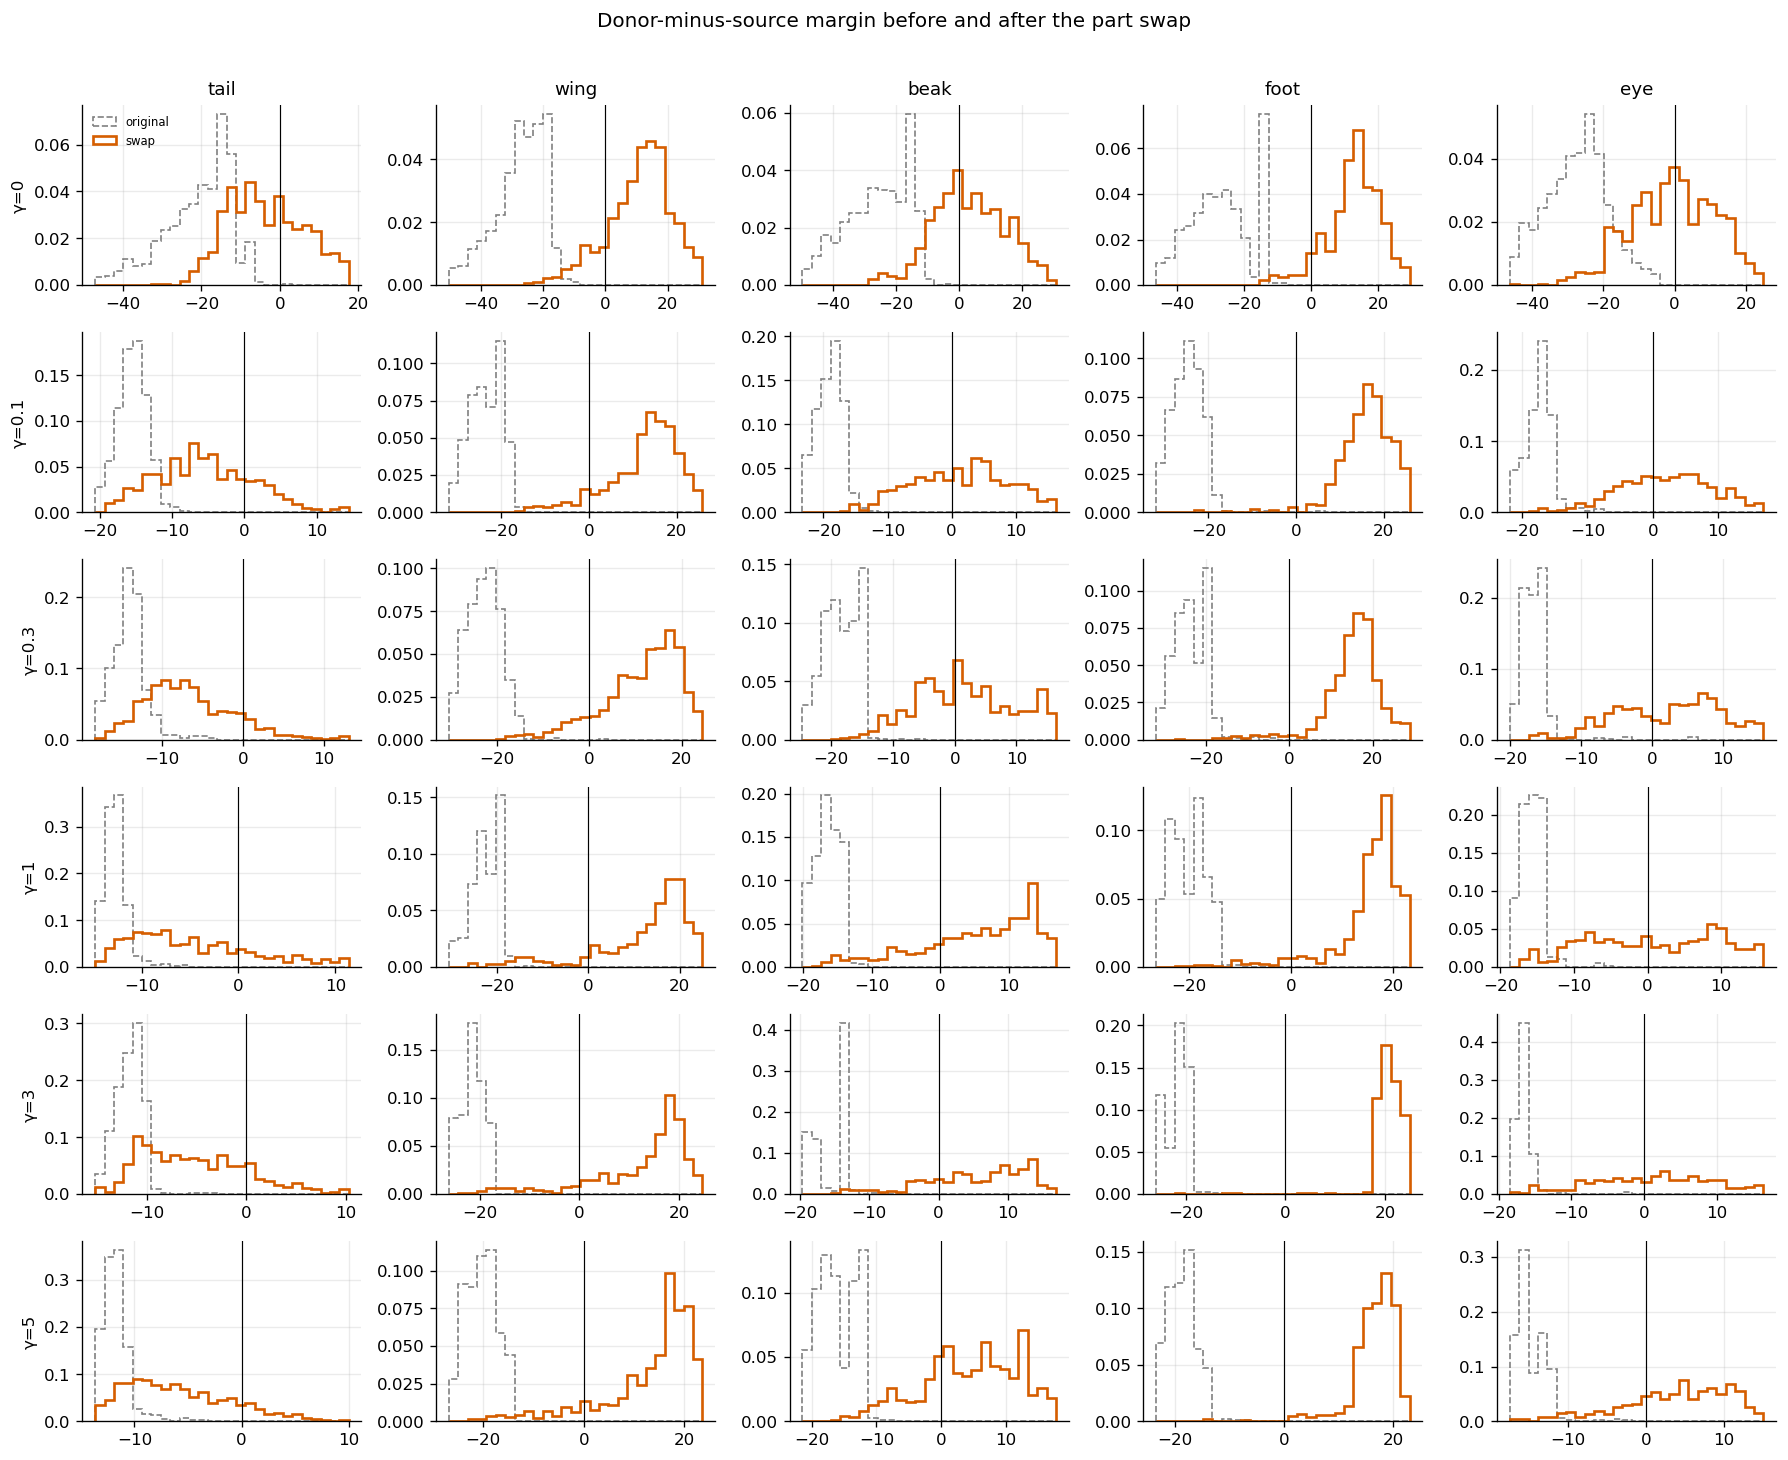

In [16]:
if SW is not None and {"margin","z_new_orig","z_old_orig"}.issubset(SW.columns):
    gammas=sorted(SW.gamma.unique())
    fig,axes=plt.subplots(len(gammas),len(ORDER),
                          figsize=(3.0*len(ORDER),2.0*len(gammas)),
                          sharex=False,sharey=False,squeeze=False)
    for i,g in enumerate(gammas):
        for j,p in enumerate(ORDER):
            d=SW[(SW.gamma==g)&(SW.part==p)]
            before=(d.z_new_orig-d.z_old_orig).dropna()
            after=d.margin.dropna()
            vals=np.r_[before.values,after.values]
            if len(vals):
                lo,hi=np.quantile(vals,[.01,.99]); bins=np.linspace(lo,hi,28)
                axes[i,j].hist(before,bins=bins,density=True,histtype="step",
                               linestyle="--",color="gray",label="original")
                axes[i,j].hist(after,bins=bins,density=True,histtype="step",
                               linewidth=1.6,color="#D55E00",label="swap")
            axes[i,j].axvline(0,color="black",linewidth=.7)
            if i==0: axes[i,j].set_title(p)
            if j==0: axes[i,j].set_ylabel(f"γ={g:g}")
    axes[0,0].legend(fontsize=7)
    fig.suptitle("Donor-minus-source margin before and after the part swap",y=1.01)
    fig.tight_layout()


**Alternative explanation.** Reused original images make rows
non-independent; read distribution positions, not apparent sample density.

**Limited conclusion rule.** A right shift shows response to the inserted pixels.
Mass remaining below zero shows that response was insufficient to overcome the
old source-associated preference.

**Next question.** With the old standard work restored, notebook 03 can now give
its limited MCBM conclusion before notebook 03rl tests the visibility-label cause.


### 6a.6 · Ordinary-image source and donor scores

**Question.** Before any intervention, is the present source concept high and
the absent donor alternative low for every part?

**Prediction.** Strong separation means the model looks grounded on ordinary
images. A later swap failure would then be intervention-specific rather than a
general inability to identify concepts.


/tmp/tmp.ZPF3OoncZx/ipykernel_2187929/2148503830.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(vals,labels=ORDER,showfliers=False)
/tmp/tmp.ZPF3OoncZx/ipykernel_2187929/2148503830.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(vals,labels=ORDER,showfliers=False)


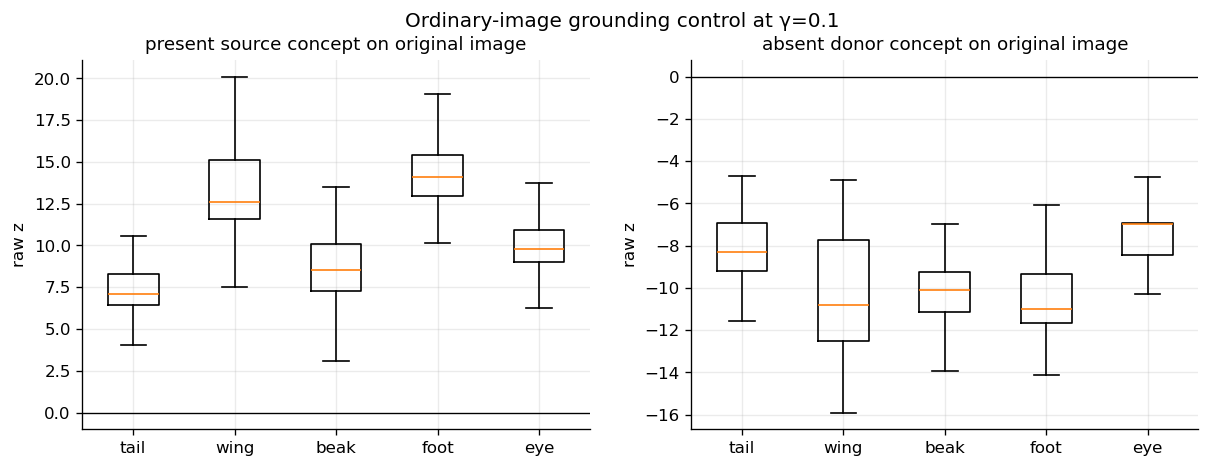

In [17]:
if SW is not None and {"z_old_orig","z_new_orig"}.issubset(SW.columns):
    gd=0.1 if 0.1 in SW.gamma.unique() else sorted(SW.gamma.unique())[0]
    d=SW[SW.gamma==gd]
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    for ax,col,title in [
        (axes[0],"z_old_orig","present source concept on original image"),
        (axes[1],"z_new_orig","absent donor concept on original image"),
    ]:
        vals=[d[d.part==p][col].dropna().values for p in ORDER]
        ax.boxplot(vals,labels=ORDER,showfliers=False)
        ax.axhline(0,color="black",linewidth=.8)
        ax.set_title(title); ax.set_ylabel("raw z")
    fig.suptitle(f"Ordinary-image grounding control at γ={gd:g}")


**Limited conclusion rule.** Separation supports ordinary-image
grounding only. It does not settle whether swapped pixels or the unchanged body
control the answer.

**Next question.** Are tail failures broad, or concentrated in particular donor
variants?


### 6a.7 · Tail margin distributions by donor variant

**Question.** Does every inserted tail variant have a similar post-swap margin,
or do particular variants fail systematically?

Each panel shows `margin=z_donor,swap−z_source,swap`. Values right of zero mean
the inserted donor tail wins.


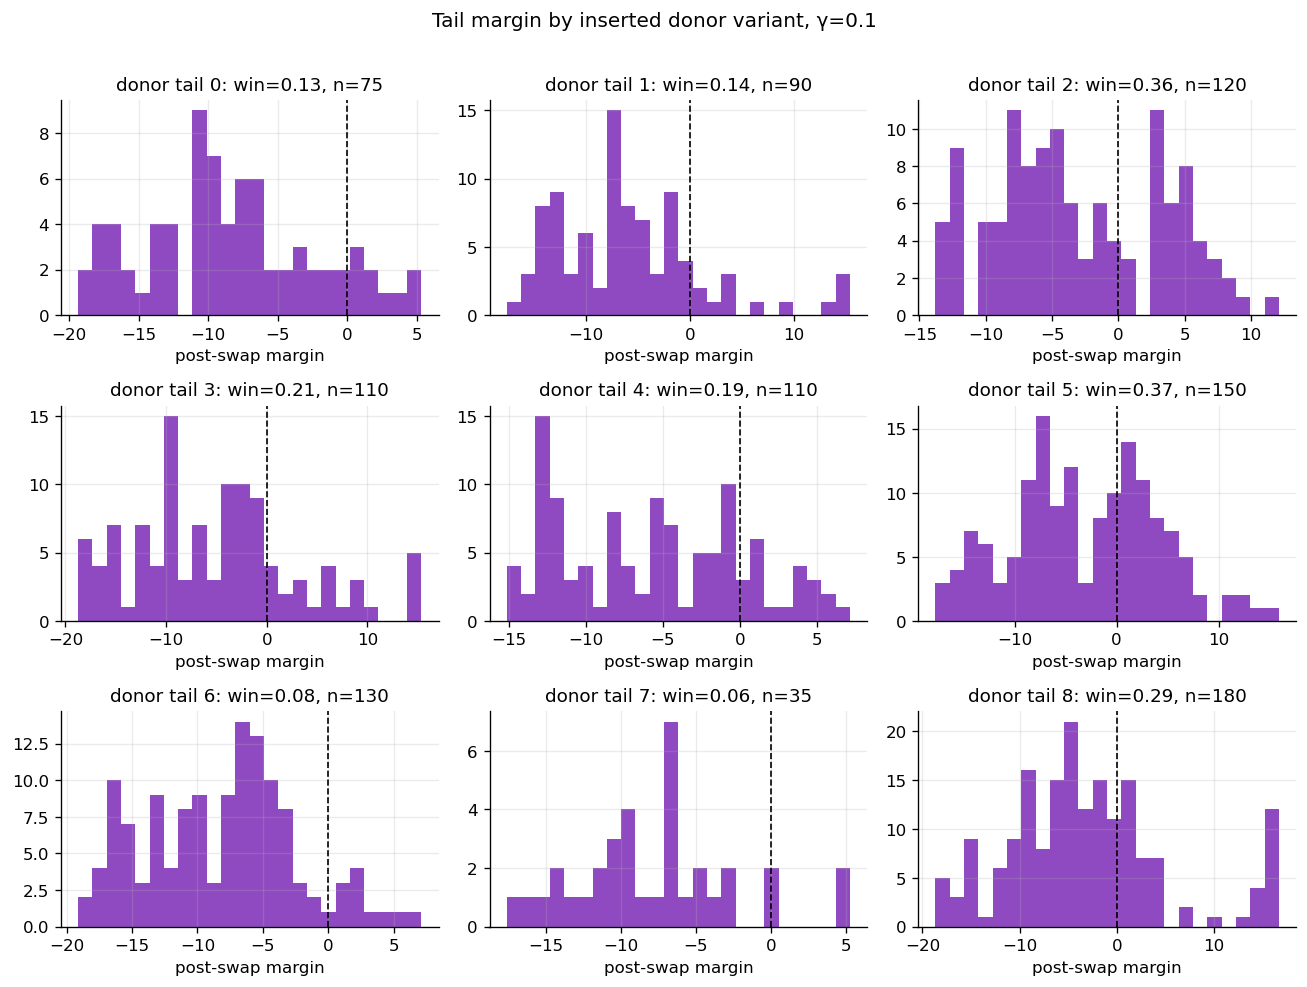

In [18]:
if SW is not None and "var_donor" in SW:
    gd=0.1 if 0.1 in SW.gamma.unique() else sorted(SW.gamma.unique())[0]
    t=SW[(SW.gamma==gd)&(SW.part=="tail")]
    variants=sorted(t.var_donor.dropna().astype(int).unique())
    ncol=3; nrow=int(np.ceil(len(variants)/ncol))
    fig,axes=plt.subplots(nrow,ncol,figsize=(11,2.7*nrow),squeeze=False)
    for ax,v in zip(axes.flat,variants):
        x=t[t.var_donor.astype(int)==v].margin.dropna()
        ax.hist(x,bins=24,color="#6a0dad",alpha=.75)
        ax.axvline(0,color="black",linestyle="--",linewidth=1)
        ax.set_title(f"donor tail {v}: win={(x>0).mean():.2f}, n={len(x)}")
        ax.set_xlabel("post-swap margin")
    for ax in axes.flat[len(variants):]: ax.axis("off")
    fig.suptitle(f"Tail margin by inserted donor variant, γ={gd:g}",y=1.01)
    fig.tight_layout()


**Alternative explanation.** Rows reuse source images and are not
independent. Compare positions and variant consistency, not histogram density.

**Limited conclusion rule.** Unequal panels establish variant-specific
difficulty. They do not alone explain why a variant fails.

**Next question.** Do forward and backward margins move together or oppose one
another?


### 6a.8 · Forward versus backward mean margin

**Question.** For each part and `γ`, is mean forward margin similar to mean
backward margin?

Points near the positive diagonal indicate direction agreement. Points near the
negative diagonal indicate direction cancellation, which produced the misleading
0.50 averages in the original broken run.


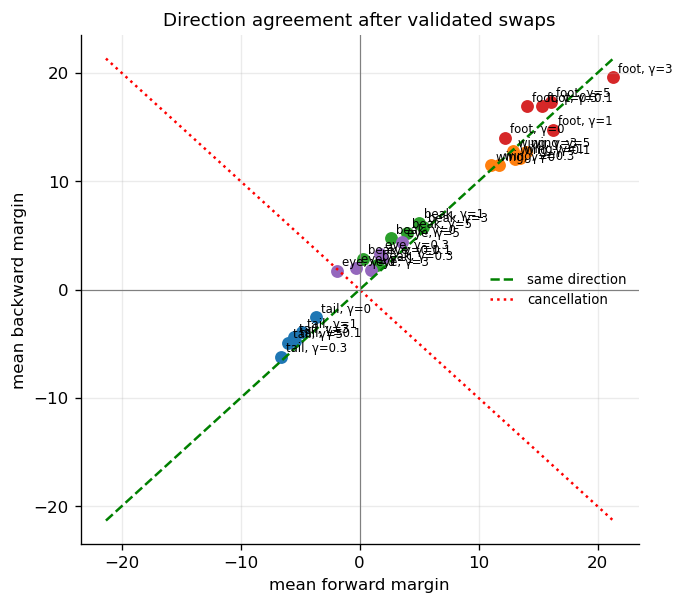

In [19]:
if SW is not None and "direction" in SW:
    M=(SW.groupby(["gamma","part","direction"]).margin.mean()
         .unstack("direction").dropna())
    fig,ax=plt.subplots(figsize=(6,5.5))
    colors={p:c for p,c in zip(ORDER,plt.cm.tab10.colors)}
    for (g,p),r in M.iterrows():
        ax.scatter(r["fwd"],r["bwd"],s=45,color=colors[p])
        ax.annotate(f"{p}, γ={g:g}",(r["fwd"],r["bwd"]),fontsize=7,
                    xytext=(3,3),textcoords="offset points")
    lim=max(abs(M[["fwd","bwd"]].values).max(),1)
    ax.plot([-lim,lim],[-lim,lim],"--",color="green",label="same direction")
    ax.plot([-lim,lim],[lim,-lim],":",color="red",label="cancellation")
    ax.axhline(0,color="gray",linewidth=.7); ax.axvline(0,color="gray",linewidth=.7)
    ax.set_xlabel("mean forward margin"); ax.set_ylabel("mean backward margin")
    ax.set_title("Direction agreement after validated swaps"); ax.legend(fontsize=8)


**Limited conclusion rule.** Positive-diagonal agreement rules out
the original cancellation artifact. It still does not identify the causal source
of a low margin.

**Next question.** Which individual concept slots remain worst as `γ` changes?


### 6a.9 · Worst concept slots across γ

**Question.** Is poor grounding confined to one corrupted slot, or repeated
across several part variants and minimality settings?

For each `γ`, rank `(part, donor variant)` by violation rate. Bars are
descriptive; their row counts must be checked before comparing close values.


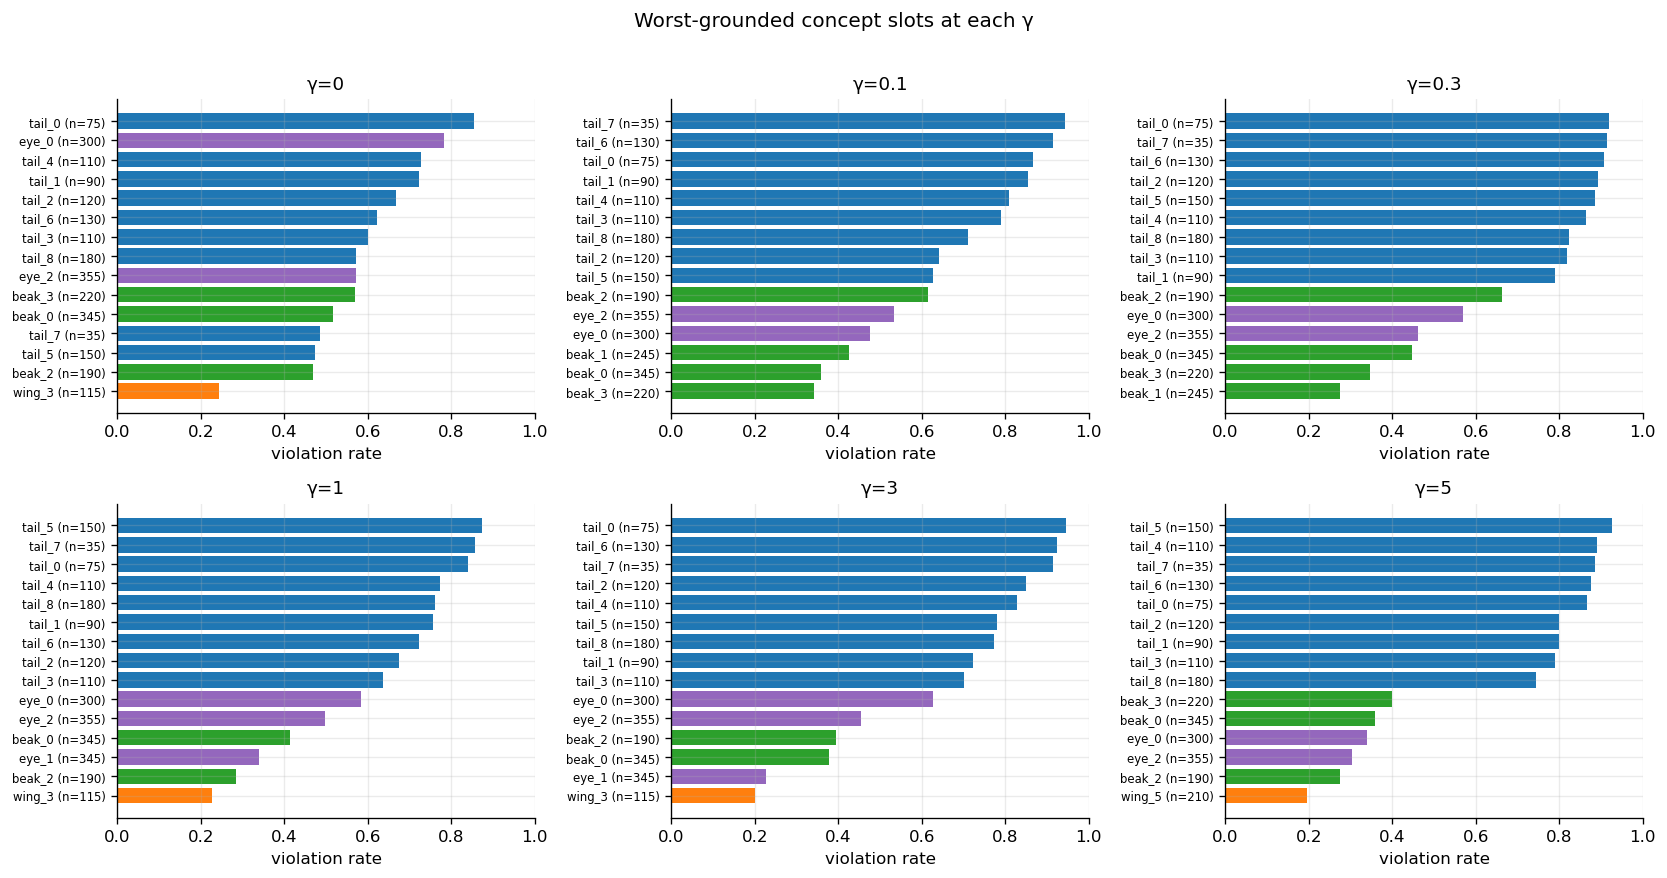

In [20]:
if SW is not None and "var_donor" in SW:
    gammas=sorted(SW.gamma.unique())
    ncol=3; nrow=int(np.ceil(len(gammas)/ncol))
    fig,axes=plt.subplots(nrow,ncol,figsize=(14,3.6*nrow),squeeze=False)
    colors={p:c for p,c in zip(ORDER,plt.cm.tab10.colors)}
    for ax,g in zip(axes.flat,gammas):
        q=(SW[SW.gamma==g].assign(violation=lambda x:~x.ordering_correct.astype(bool))
             .groupby(["part","var_donor"]).agg(rate=("violation","mean"),
                                                 n=("violation","size"))
             .reset_index().sort_values("rate",ascending=False).head(15))
        labels=[f"{p}_{int(v)} (n={n})" for p,v,n in
                zip(q.part,q.var_donor,q.n)]
        ax.barh(range(len(q)),q.rate,color=[colors[p] for p in q.part])
        ax.set_yticks(range(len(q))); ax.set_yticklabels(labels,fontsize=7)
        ax.invert_yaxis(); ax.set_xlim(0,1); ax.set_title(f"γ={g:g}")
        ax.set_xlabel("violation rate")
    for ax in axes.flat[len(gammas):]: ax.axis("off")
    fig.suptitle("Worst-grounded concept slots at each γ",y=1.01)
    fig.tight_layout()


**Limited conclusion rule.** Repeated tail, beak, or eye slots support
a graded multi-part problem. A single high bar with small `n` is not enough.

**Next question.** Does visible pixel area explain the remaining tail failures?


### 6a.10 · Tail visibility versus margin

**Question.** Among validated swaps, does a larger visible inserted tail produce
a larger margin, and do failures disappear above a reasonable visibility level?

The left panel plots pixels against margin. The right compares visibility
distributions for donor wins and violations.


/tmp/tmp.ZPF3OoncZx/ipykernel_2187929/1318679364.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(vals,labels=["donor wins","violation"],showfliers=False)


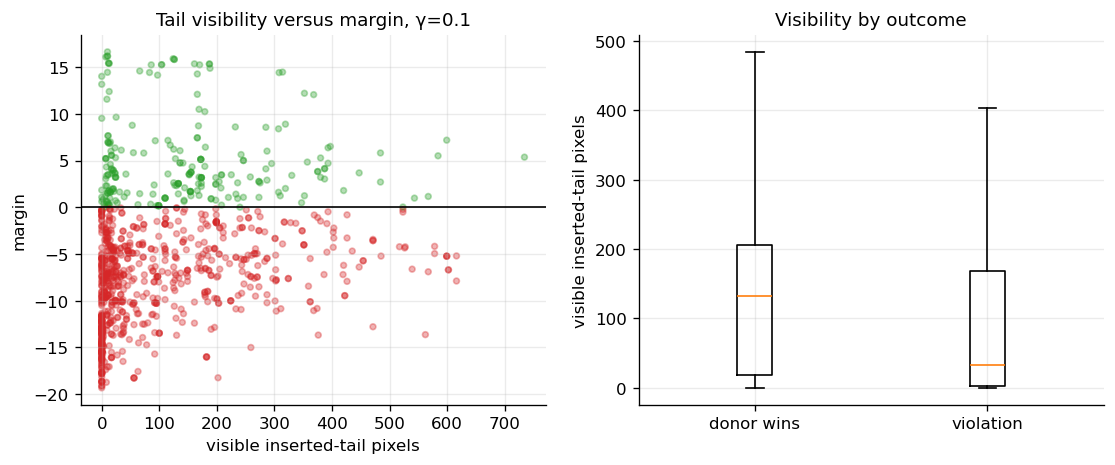

In [21]:
if SW is not None and "pixel_count_cf" in SW:
    gd=0.1 if 0.1 in SW.gamma.unique() else sorted(SW.gamma.unique())[0]
    t=SW[(SW.gamma==gd)&(SW.part=="tail")].copy()
    t["outcome"]=np.where(t.ordering_correct.astype(bool),"donor wins","violation")
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    axes[0].scatter(t.pixel_count_cf,t.margin,s=12,alpha=.35,
                    c=np.where(t.ordering_correct.astype(bool),"#2ca02c","#d62728"))
    axes[0].axhline(0,color="black",linewidth=1)
    axes[0].set_xlabel("visible inserted-tail pixels"); axes[0].set_ylabel("margin")
    axes[0].set_title(f"Tail visibility versus margin, γ={gd:g}")
    vals=[t[t.outcome==o].pixel_count_cf.values for o in ["donor wins","violation"]]
    axes[1].boxplot(vals,labels=["donor wins","violation"],showfliers=False)
    axes[1].set_ylabel("visible inserted-tail pixels")
    axes[1].set_title("Visibility by outcome")


**Limited conclusion rule.** Overlap at high visibility rejects
occlusion as the only explanation. A shift between groups still supports
visibility as a partial explanation.

**Next question.** Why are CBM and MCBM raw `z` values numerically different even
when `γ=0`?


### 6a.11 · CBM versus MCBM raw-score scale

**Question.** Can raw CBM and MCBM margin magnitudes be compared directly?

No: their bottleneck parameterizations differ. This control shows their
ordinary-image `z_source` distributions. Ordering signs and within-model changes
remain comparable; raw magnitudes do not.


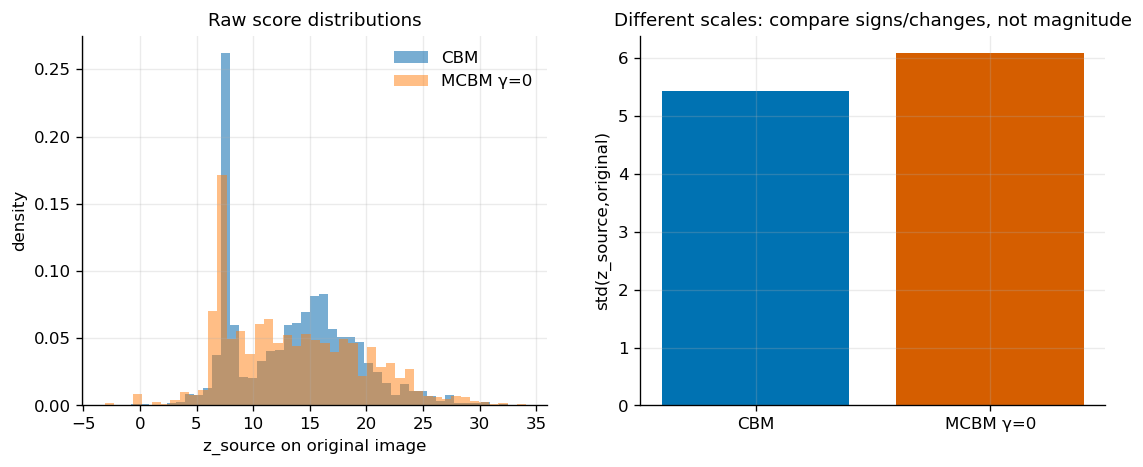

In [22]:
if SW is not None and CB is not None and "z_old_orig" in CB:
    g0=sorted(SW.gamma.unique())[0]
    a=CB.z_old_orig.dropna().values
    b=SW[SW.gamma==g0].z_old_orig.dropna().values
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    axes[0].hist(a,bins=45,density=True,alpha=.6,label="CBM")
    axes[0].hist(b,bins=45,density=True,alpha=.5,label=f"MCBM γ={g0:g}")
    axes[0].set_xlabel("z_source on original image"); axes[0].set_ylabel("density")
    axes[0].set_title("Raw score distributions"); axes[0].legend()
    axes[1].bar(["CBM",f"MCBM γ={g0:g}"],[np.std(a),np.std(b)],
                color=[CBM_C,MCBM_C])
    axes[1].set_ylabel("std(z_source,original)")
    axes[1].set_title("Different scales: compare signs/changes, not magnitude")


**Limited conclusion.** CBM and MCBM `γ=0` overlap substantially on this
raw-score control. That rules out a large baseline scale mismatch as the
explanation for their ordering difference here. Raw magnitudes still should
not be compared across compressed `γ≥0.1` models without a within-model
normalization. Scale does not explain within-model part differences or the
sign of the swap response.

Notebook 03 now retains the useful questions from the original 20 figures while
recomputing them on the validated renders and excluding plots whose only content
was the known broken 0.50/zero-visibility artifact.


### 6a.12 · Visibility across every part

**Question.** Is visibility related only to tail failure, or do beak, eye, wing,
and foot show their own visibility-response patterns as `γ` changes?

For each `γ`, each line is one part. The x-axis uses fixed visible-pixel bins and
the y-axis is `P(margin>0)`. The printed table includes `n`, because bins with few
swaps should not drive a conclusion.


/tmp/tmp.ZPF3OoncZx/ipykernel_2187929/1410139533.py:28: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  display(Q.pivot_table(index=["gamma","part","visibility_bin"],


follow      n
gamma part visibility_bin               
0.0   beak 0-20             0.523  128.0
           21-50            0.491  163.0
           51-100           0.511  190.0
           101-200          0.532  235.0
           201-500          0.719  231.0
...                           ...    ...
5.0   wing 21-50            0.833   18.0
           51-100           0.857   56.0
           101-200          0.826  121.0
           201-500          0.876  347.0
           >500             0.954  326.0

[174 rows x 2 columns]

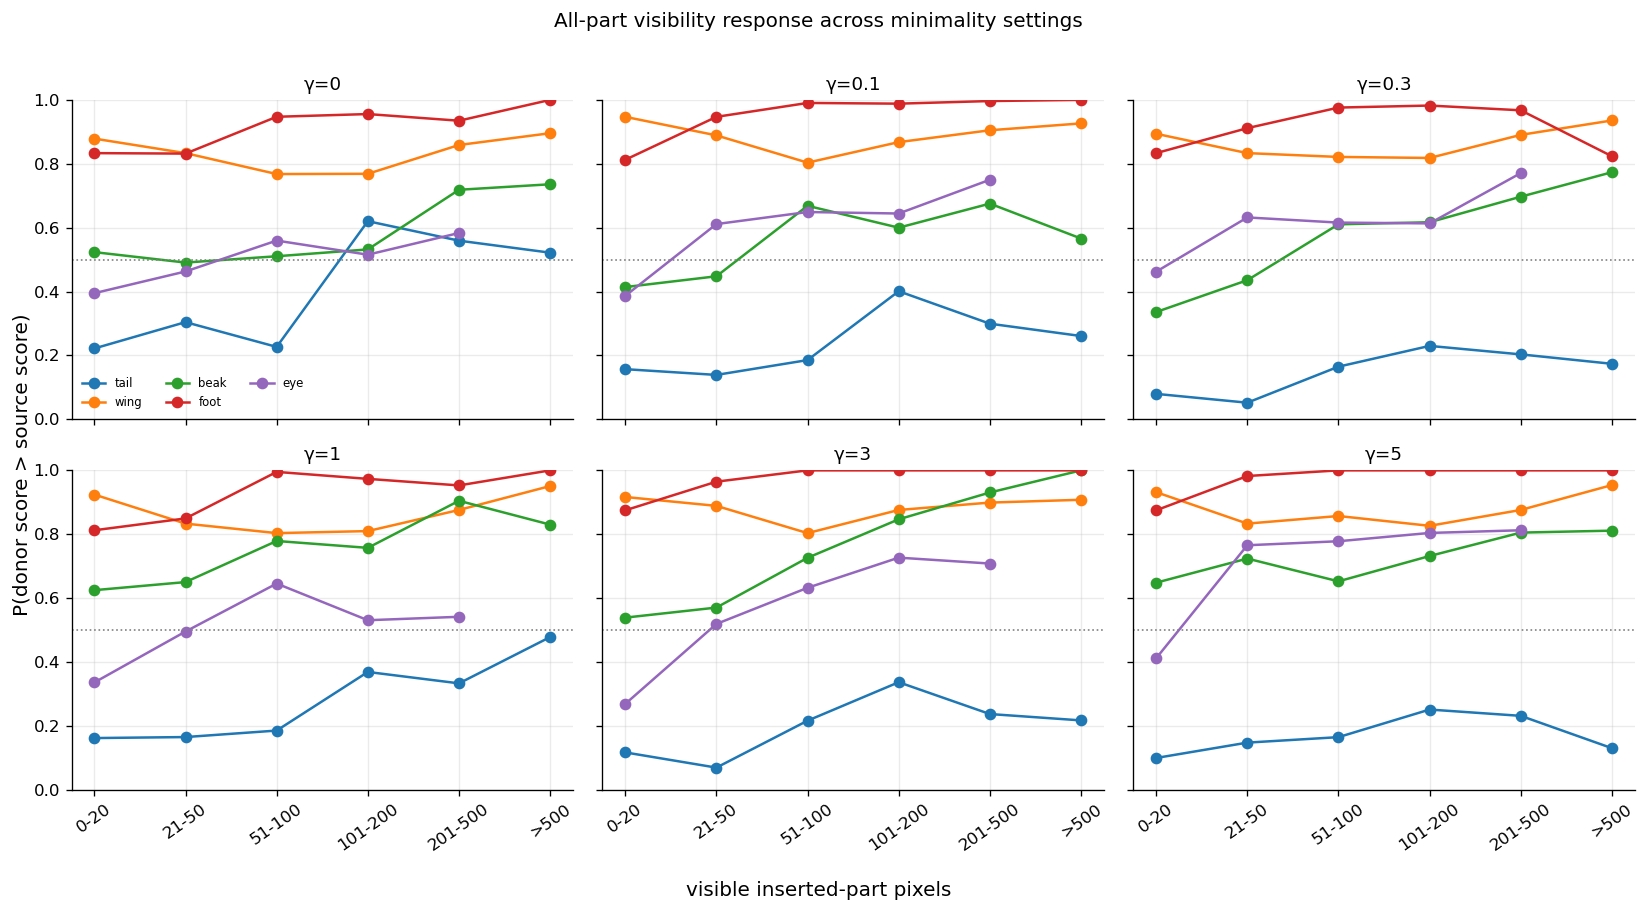

In [23]:
if SW is not None and "pixel_count_cf" in SW:
    bins=[-1,20,50,100,200,500,np.inf]
    labels=["0-20","21-50","51-100","101-200","201-500",">500"]
    V=SW.copy()
    V["visibility_bin"]=pd.cut(V.pixel_count_cf,bins=bins,labels=labels)
    Q=(V.groupby(["gamma","part","visibility_bin"],observed=True)
         .agg(follow=("ordering_correct","mean"),n=("ordering_correct","size"))
         .reset_index())
    gammas=sorted(V.gamma.unique()); ncol=3
    nrow=int(np.ceil(len(gammas)/ncol))
    fig,axes=plt.subplots(nrow,ncol,figsize=(14,3.7*nrow),
                          sharex=True,sharey=True,squeeze=False)
    colors={p:c for p,c in zip(ORDER,plt.cm.tab10.colors)}
    for ax,g in zip(axes.flat,gammas):
        for p in ORDER:
            d=Q[(Q.gamma==g)&(Q.part==p)]
            x=[labels.index(str(v)) for v in d.visibility_bin]
            ax.plot(x,d.follow,marker="o",label=p,color=colors[p])
        ax.axhline(.5,color="gray",linestyle=":",linewidth=1)
        ax.set_title(f"γ={g:g}"); ax.set_ylim(0,1)
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels,rotation=35)
    for ax in axes.flat[len(gammas):]: ax.axis("off")
    axes.flat[0].legend(ncol=3,fontsize=7)
    fig.supxlabel("visible inserted-part pixels")
    fig.supylabel("P(donor score > source score)")
    fig.suptitle("All-part visibility response across minimality settings",y=1.01)
    fig.tight_layout()
    display(Q.pivot_table(index=["gamma","part","visibility_bin"],
                          values=["follow","n"]).round(3))


**Interpretation rule.** A rising curve supports visibility as one
cause for that part. A curve that remains low in well-populated high-visibility
bins rejects visibility as the only cause. Differences between parts must not be
read from empty or tiny bins.

**Next question.** After mapping these standard-model explanations, notebook
03rl tests whether visibility-aware training labels change the same responses.


## Evidence chain: observation, explanation, test

1. **Did minimality actually change the model?** Yes: `γ` sharply compresses
   `z`, while ordinary concept and species accuracy stay high.
2. **Did that improve visual grounding?** No: tail replacement wins become less
   frequent when minimality turns on, while wing and foot remain strong.
3. **That is the odd result.** `response_delta` remains positive. Inserting a
   tail moves the donor-versus-source scores in the correct direction, so the
   model is not simply blind to the tail. The movement is weaker than for
   grounded parts and often does not cross zero.
4. **Could visibility explain it?** Visible-only filtering helps, but tail stays
   far below foot. Visibility is partial, not sufficient.
5. **Could one bad tail slot explain it?** The all-part confusion matrix,
   donor-variant margins, and worst-slot plots test this. Variants are unequal,
   but the problem is not confined to one slot.
6. **Could variant composition masquerade as species?** The variant-pair panel
   comes first. The within-variant residual panel then asks whether source-body
   or species differences remain after subtracting each source variant's mean.
7. **Could raw-score scale explain it?** CBM and MCBM use different `z` scales,
   so magnitudes cannot be compared across model families. The within-model
   ordering and response conclusions survive that control.
8. **Limited conclusion.** Minimality changes and compresses the bottleneck but
   does not guarantee that named slots follow their named visible parts. The
   strongest demonstrated failure is explanatory grounding; downstream
   species-probability changes remain small.
9. **Next causal question.** Training labels remain positive when a
   non-placeholder part is effectively invisible, especially for tails.
   Notebook 03rl changes those labels while holding images and training
   membership fixed. It is the next test, not a replacement for this evidence.


## 7 · Conclusion and decisive next experiment

Current MCBM runs establish:

1. `γ` compresses `z` without destroying ordinary accuracy.
2. Compression does not guarantee that a concept follows its named pixels.
3. Tail's normalized donor response becomes much smaller when minimality is on.
4. Wing and foot remain grounded controls.
5. Visibility explains only part of the tail gap.

Minimality controls **what remains in `z_j` after the answer is formed**. It does not control **which pixels formed the answer**.

The decisive grounding design independently varies part identity `T` and body/species `B`:

`z_tail = f(T,B)`.

Hold `T` fixed and change only `B`; any systematic change in `z_tail` is a causal non-tail effect. Hold `B` fixed and change only `T`; this is the intended tail effect. Repeat for every output slot to detect tail→beak/wing/eye/foot spillover.

Relabelled training then tests why the effect arose. The same relabeling idea can and should be applied to a standard CBM as well as MCBM; comparing CBM vs CBM-RL isolates the data-label change without the minimality term.


## Provenance

The swap, direction, visibility, compression, seed, deletion, probe, and downstream ideas come from the complete original MCBM renderer notebook. They are reordered here so each test states its variables and decision rule before showing the result.
